# TFM — 01. EDA: Análisis exploratorio de accidentes de tráfico en Madrid (2012-2018)
**Autora:** Meritxell Abellan Collado  
**Dataset:** Accidentes de tráfico en Madrid (Open Data Ayuntamiento de Madrid)  

---

## Estructura del notebook

Este notebook recoge el análisis exploratorio completo en dos niveles:

- **EDA I (Secciones 1-3):** Análisis a nivel persona — distribución de la variable "Lesividad" y perfil de los implicados.
- **EDA II (Secciones 4-9):** Análisis a nivel accidente — variable objetivo, análisis temporal, geográfico, condiciones del siniestro y asociación estadística.


---
## 0. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, shapiro, kstest
import warnings
import geopandas as gpd
import folium
import requests
import json
import osmnx as ox


warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Paleta de colores global para lesividad
COLOR_SIN_DATO       = '#bdc3c7'
COLORES_LESIVIDAD    = {'IL': '#2ecc71', 'HL': '#f1c40f', 'HG': '#e67e22', 'MT': '#e74c3c'}
ORDEN_LESIVIDAD      = ['IL', 'HL', 'HG', 'MT']
ORDEN_LESIVIDAD_EXT  = ORDEN_LESIVIDAD + ['Sin dato']
COLORES_LESIVIDAD_EXT = {**COLORES_LESIVIDAD, 'Sin dato': COLOR_SIN_DATO}
LABELS_LESIVIDAD_EXT = ['Ileso', 'Herido leve', 'Herido grave', 'Fallecido', 'Sin dato']

COLORES_GRAVE         = {0: 'steelblue', 1: '#e74c3c'}
LABELS_GRAVE          = {0: 'No grave', 1: 'Grave'}
COLORES_GRAVE_EXT     = {**COLORES_GRAVE, 'Sin dato': COLOR_SIN_DATO}
LABELS_GRAVE_EXT      = {0: 'No grave', 1: 'Grave', 'Sin dato': 'Sin dato'}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# Carga del dataset
import sys
sys.path.append('..')
from src.pipelines.limpieza import limpiar_database

DATA_PATH = '../data/raw/accidentes-trafico.xlsx'
df = pd.read_excel(DATA_PATH)

# Limpieza estructural: texto, encoding, fecha, exclusión de testigos.
# La eliminación de duplicados y la normalización de nulos se aplican más
# abajo, tras auditar los duplicados en la Sección 1 (ver nota siguiente).
df = limpiar_database(df)

print(f'Registros nivel persona (tras excluir testigos): {len(df):>8,}')
print(f'Accidentes únicos:                               {df["Nº PARTE"].nunique():>8,}')

Registros originales:        199,078
Testigos excluidos:            24,725
Tras excluir testigos:        174,353
Registros nivel persona (tras excluir testigos):  174,353
Accidentes únicos:                                 68,773


### Nota sobre la estructura de dataframes y coherencia con `01_EDA_personas.ipynb`

En este notebook se usan tres dataframes de trabajo globales:

- **`df`** — todos los implicados directos (sin testigos). En la Sección 1 se audita
  todavía **con duplicados exactos**, antes de decidir cómo tratarlos; a partir del
  final de la Sección 1 ya está deduplicado y con los valores "sin dato" normalizados.
- **`df_sin_na`** — subconjunto de `df` (ya limpio) con lesividad conocida (`IL`, `HL`, `HG`, `MT`).
- **`df_accidentes`** — dataset agregado a nivel accidente con la variable objetivo `accidente_grave`.

Esta estructura garantiza coherencia entre ambos notebooks: los registros sin lesividad
asignada se excluyen siempre de los análisis de gravedad.

---
# EDA I: Análisis a nivel persona

---
## 1. Entendimiento del dataset

Antes de cualquier análisis, es fundamental entender qué contiene el dataset: qué representa cada columna, cuántos registros hay, qué tipos de datos se usan y si existen valores nulos o inconsistentes.

El dataset recoge información a nivel persona: para cada accidente (`Nº PARTE`) puede haber varias filas, una por cada persona implicada (conductor, peatón, viajero, testigo). Las variables se pueden agrupar en:
- **Identificación:** `Nº PARTE`, `Nº`, `FECHA`
- **Tiempo:** `RANGO HORARIO`, `DIA SEMANA`
- **Lugar:** `DISTRITO`, `LUGAR ACCIDENTE`
- **Condiciones atmosféricas:** columnas `CPFA_*`
- **Estado del firme:** columnas `CPSV_*`
- **Accidente:** `TIPO ACCIDENTE`, `Nº VICTIMAS *`
- **Persona:** `Tipo Vehiculo`, `TIPO PERSONA`, `SEXO`, `Tramo Edad`
- **Variable objetivo:** `LESIVIDAD`

In [3]:
# Primeras filas
df.head()

,FECHA,RANGO HORARIO,DIA SEMANA,DISTRITO,LUGAR ACCIDENTE,Nº,Nº PARTE,CPFA Granizo,CPFA Hielo,CPFA Lluvia,...,CPSV Seca Y Limpia,Nº VICTIMAS *,TIPO ACCIDENTE,Tipo Vehiculo,TIPO PERSONA,SEXO,LESIVIDAD,Tramo Edad,AÑO,MES
0,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,NO ASIGNADO,PEATON,HOMBRE,HL,DE 25 A 29 AÑOS,2012,1
1,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,NO ASIGNADO,PEATON,MUJER,HL,DE 25 A 29 AÑOS,2012,1
3,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,AUTO-TAXI,CONDUCTOR,HOMBRE,IL,DE 35 A 39 AÑOS,2012,1
4,2012-01-01,DE 2:00 A 2:59,DOMINGO,PUENTE DE VALLECAS,AVENIDA DE SAN DIEGO NUM,96.0,2012/118,NO,NO,NO,...,SI,1,OTRAS CAUSAS,TURISMO,CONDUCTOR,HOMBRE,IL,DE 25 A 29 AÑOS,2012,1
5,2012-01-01,DE 2:00 A 2:59,DOMINGO,PUENTE DE VALLECAS,AVENIDA DE SAN DIEGO NUM,96.0,2012/118,NO,NO,NO,...,SI,1,OTRAS CAUSAS,TURISMO,CONDUCTOR,HOMBRE,IL,DE 35 A 39 AÑOS,2012,1


In [4]:
# Resumen descriptivo
import pandas.api.types as pat

resumen = []
for col in df.columns:
    info = {
        'Variable':  col,
        'Tipo':      str(df[col].dtype),
        'No nulos':  df[col].notna().sum(),
        'Nulos (%)': round(df[col].isnull().mean() * 100, 2),
        'Únicos':    df[col].nunique(),
        'Valor más frecuente':     pd.NA,
        'Frec. más frecuente (%)': pd.NA,
        'Media':   pd.NA,
        'Mediana': pd.NA,
        'Std':     pd.NA,
    }
    if pat.is_string_dtype(df[col]) or pat.is_object_dtype(df[col]):
        moda = df[col].value_counts()
        info['Valor más frecuente']     = moda.idxmax() if not moda.empty else pd.NA
        info['Frec. más frecuente (%)'] = round(moda.max() / moda.sum() * 100, 2) if not moda.empty else pd.NA
    elif pat.is_numeric_dtype(df[col]):
        moda = df[col].mode()
        info['Valor más frecuente']     = moda[0] if not moda.empty else pd.NA
        info['Frec. más frecuente (%)'] = round((df[col] == moda[0]).mean() * 100, 2) if not moda.empty else pd.NA
        info['Media']   = round(df[col].mean(), 2)
        info['Mediana'] = round(df[col].median(), 2)
        info['Std']     = round(df[col].std(), 2)
    # datetime → se omiten estadísticos numéricos (ya visible en df.info())
    elif pat.is_datetime64_any_dtype(df[col]):
        moda = df[col].mode()
        info['Valor más frecuente']     = moda[0].date() if not moda.empty else pd.NA
        info['Frec. más frecuente (%)'] = round((df[col] == moda[0]).mean() * 100, 2) if not moda.empty else pd.NA
    resumen.append(info)

pd.DataFrame(resumen).set_index('Variable')

,Tipo,No nulos,Nulos (%),Únicos,Valor más frecuente,Frec. más frecuente (%),Media,Mediana,Std
Variable,,,,,,,,,
FECHA,datetime64[us],174353,0.00,2557,2013-10-25,0.11,<NA>,<NA>,<NA>
RANGO HORARIO,str,174353,0.00,24,DE 14:00 A 14:59,7.39,<NA>,<NA>,<NA>
DIA SEMANA,str,174353,0.00,7,VIERNES,17.13,<NA>,<NA>,<NA>
DISTRITO,str,174353,0.00,21,SALAMANCA,7.55,<NA>,<NA>,<NA>
LUGAR ACCIDENTE,str,174353,0.00,13958,AUTOVIA M-30 CALZADA 1 KM.,3.42,<NA>,<NA>,<NA>
Nº,float64,171680,1.53,862,0.0,47.37,1039.17,1.0,4052.98
Nº PARTE,str,174353,0.00,68773,2012/11769,0.02,<NA>,<NA>,<NA>
CPFA Granizo,str,174353,0.00,2,NO,99.99,<NA>,<NA>,<NA>
CPFA Hielo,str,174353,0.00,2,NO,99.95,<NA>,<NA>,<NA>


In [5]:
# Número de accidentes únicos
n_accidentes = df['Nº PARTE'].nunique()
n_personas   = len(df)
print(f'Registros totales (nivel persona): {n_personas:,}')
print(f'Accidentes únicos (nivel accidente): {n_accidentes:,}')
print(f'Media de personas implicadas por accidente: {n_personas / n_accidentes:.2f} (incluyendo ilesos)')

Registros totales (nivel persona): 174,353
Accidentes únicos (nivel accidente): 68,773
Media de personas implicadas por accidente: 2.54 (incluyendo ilesos)


In [6]:
# Duplicados exactos (todas las columnas)
duplicados = df.duplicated().sum()
print(f'Duplicados exactos (todas las columnas): {duplicados:,}')

# Duplicados por campos clave (misma persona en el mismo accidente, aunque difieran en otras columnas)
duplicados_clave = df.duplicated(subset=['Nº PARTE', 'TIPO PERSONA', 'SEXO', 'Tramo Edad', 'LESIVIDAD']).sum()
print(f'Posibles duplicados por campos clave: {duplicados_clave:,}',
      '(no se eliminan aquí: pueden diferir en otras columnas relevantes)')

Duplicados exactos (todas las columnas): 4,065
Posibles duplicados por campos clave: 4,766 (no se eliminan aquí: pueden diferir en otras columnas relevantes)


In [7]:
# ── 1. Muestra de duplicados exactos ──────────────────────────────────────────
dupl_exactos = df[df.duplicated(keep=False)].sort_values(by=['Nº PARTE', 'TIPO PERSONA'])
print("=== MUESTRA DE DUPLICADOS EXACTOS (primeras 10 filas) ===")
print(dupl_exactos.head(10).to_string())

# ── 2. ¿Los duplicados exactos comparten el mismo Nº PARTE? ───────────────────
print("\n¿Duplicados exactos comparten Nº PARTE?")
print(dupl_exactos.duplicated(subset=['Nº PARTE'], keep=False).value_counts())

# ── 3. Muestra de duplicados por campos clave ─────────────────────────────────
campos_clave = ['Nº PARTE', 'TIPO PERSONA', 'SEXO', 'Tramo Edad', 'LESIVIDAD']
dupl_clave = df[df.duplicated(subset=campos_clave, keep=False)].sort_values(by=campos_clave)
print("\n=== MUESTRA DUPLICADOS POR CAMPOS CLAVE (primeras 10) ===")
print(dupl_clave.head(10).to_string())

# ── 4. ¿Los duplicados "clave" difieren en otras columnas? ────────────────────
# Si sí → mismo perfil, datos distintos (posible error de registro)
# Si no → filas 100% idénticas capturadas también aquí
diff_en_otras = dupl_clave[~dupl_clave.duplicated(keep=False)]
print(f"\nDuplicados por clave que NO son exactos (difieren en otras cols): {len(diff_en_otras):,}")
print("Ejemplo:")
print(diff_en_otras.head(6).to_string())

# ── 5. Distribución: ¿cuántas veces aparece cada grupo duplicado? ─────────────
conteo = dupl_clave.groupby(campos_clave).size().value_counts().rename("nº grupos")
print("\nVeces que se repite cada combinación de campos clave:")
print(conteo)

# ── 6. Decisión de limpieza: eliminar duplicados exactos ─────────────────────
from src.pipelines.limpieza import eliminar_duplicados
df = eliminar_duplicados(df)

=== MUESTRA DE DUPLICADOS EXACTOS (primeras 10 filas) ===
           FECHA     RANGO HORARIO DIA SEMANA             DISTRITO                                      LUGAR ACCIDENTE     Nº    Nº PARTE CPFA Granizo CPFA Hielo CPFA Lluvia CPFA Niebla CPFA Seco CPFA Nieve CPSV Mojada CPSV Aceite CPSV Barro CPSV Grava Suelta CPSV Hielo CPSV Seca Y Limpia  Nº VICTIMAS *          TIPO ACCIDENTE Tipo Vehiculo TIPO PERSONA         SEXO    LESIVIDAD       Tramo Edad   AÑO  MES
22306 2012-11-03    DE 6:00 A 6:59     SABADO  FUENCARRAL-EL PARDO   CALLE DE SINESIO DELGADO - AUTOVIA  M-30 CALZADA 1    0.0  2012/10013           NO         NO          SI          NO        NO         NO          SI          NO         NO                NO         NO                 NO              4  CHOQUE CON OBJETO FIJO       TURISMO      VIAJERO       HOMBRE           HL  DE 25 A 29 AÑOS  2012   11
22307 2012-11-03    DE 6:00 A 6:59     SABADO  FUENCARRAL-EL PARDO   CALLE DE SINESIO DELGADO - AUTOVIA  M-30 CALZADA 1 

Duplicados exactos eliminados:    4,065 (2.33%)
Filas tras eliminar duplicados:  170,288


Nota sobre duplicados: No es posible determinar con certeza si los 4.065 duplicados exactos
son errores de exportación o personas distintas con perfil completamente idéntico en el mismo
accidente. Dado que la probabilidad de coincidencia total en todas las variables — incluyendo
vehículo, lesividad, tramo de edad y sexo — es muy baja, se asume que son registros duplicados
y se eliminan (paso 6 de la celda anterior). Se reconoce esta limitación.

Los 701 duplicados por campos clave **no se eliminan**: podrían ser personas distintas con el
mismo perfil demográfico en el mismo accidente, y difieren en otras columnas relevantes
(p. ej. tipo de vehículo). Se documentan como limitación de calidad del dato, no se corrigen.

In [8]:
from src.pipelines.limpieza import normalizar_nulos

# Normalización de nulos ('NO ASIGNADO'/'DESCONOCIDO' -> NaN)
df = normalizar_nulos(df)

# Dataframe global sin LESIVIDAD 'NO ASIGNADA' y con columna GRAVE
df_sin_na = df[df['LESIVIDAD'].isin(ORDEN_LESIVIDAD)].copy()
df_sin_na['GRAVE'] = df_sin_na['LESIVIDAD'].isin(['HG', 'MT']).astype(int)

print(f'Registros nivel persona (df, ya limpio):  {len(df):>8,}')
print(f'  └─ Sin LESIVIDAD NO ASIGNADA:            {len(df_sin_na):>8,}')
print(f'Accidentes únicos:                         {df["Nº PARTE"].nunique():>8,}')

Nulos tras normalizar valores "sin dato": 34,924
Registros nivel persona (df, ya limpio):   170,288
  └─ Sin LESIVIDAD NO ASIGNADA:             163,853
Accidentes únicos:                           68,773


In [9]:
# Rango temporal del dataset
print(f'Desde: {df["FECHA"].min().date()}')
print(f'Hasta: {df["FECHA"].max().date()}')
print(f'Años cubiertos: {sorted(df["FECHA"].dt.year.unique())}')

Desde: 2012-01-01
Hasta: 2018-12-31
Años cubiertos: [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [10]:
# Valores únicos por columna categórica
cols_categoricas = df.select_dtypes(include='object').columns
for col in cols_categoricas:
    valores = df[col].unique()
    print(f'\n{col} ({len(valores)} valores únicos):')
    print(sorted([str(v) for v in valores]))


RANGO HORARIO (24 valores únicos):
['DE 00:00 A 00:59', 'DE 10:00 A 10:59', 'DE 11:00 A 11:59', 'DE 12:00 A 12:59', 'DE 13:00 A 13:59', 'DE 14:00 A 14:59', 'DE 15:00 A 15:59', 'DE 16:00 A 16:59', 'DE 17:00 A 17:59', 'DE 18:00 A 18:59', 'DE 19:00 A 19:59', 'DE 1:00 A 1:59', 'DE 20:00 A 20:59', 'DE 21:00 A 21:59', 'DE 22:00 A 22:59', 'DE 23:00 A 23:59', 'DE 2:00 A 2:59', 'DE 3:00 A 3:59', 'DE 4:00 A 4:59', 'DE 5:00 A 5:59', 'DE 6:00 A 6:59', 'DE 7:00 A 7:59', 'DE 8:00 A 8:59', 'DE 9:00 A 9:59']

DIA SEMANA (7 valores únicos):
['DOMINGO', 'JUEVES', 'LUNES', 'MARTES', 'MIERCOLES', 'SABADO', 'VIERNES']

DISTRITO (21 valores únicos):
['ARGANZUELA', 'BARAJAS', 'CARABANCHEL', 'CENTRO', 'CHAMARTIN', 'CHAMBERI', 'CIUDAD LINEAL', 'FUENCARRAL-EL PARDO', 'HORTALEZA', 'LATINA', 'MONCLOA-ARAVACA', 'MORATALAZ', 'PUENTE DE VALLECAS', 'RETIRO', 'SALAMANCA', 'SAN BLAS', 'TETUAN', 'USERA', 'VICALVARO', 'VILLA DE VALLECAS', 'VILLAVERDE']



LUGAR ACCIDENTE (13958 valores únicos):
['ACCESO  M-40 SALIDA AVDA. DEL PADRE HUIDOBRO-DIR.MADRID - AUTOVIA  M-23 SALIDA', 'ACCESO  NUDO DE MANOTERAS', 'ACCESO  NUDO DE MANOTERAS - AVENIDA DE BURGOS', 'ACCESO  NUDO NORTE', 'ACCESO  NUDO SUR', 'ACCESO  PASEO EXTREMADURA - CALLE DE CARABIAS', 'ACCESO  PASEO EXTREMADURA - CALLE DE LA HUERTA DE CASTAÑEDA', 'ACCESO  PASEO EXTREMADURA - CALLE DE LOS YEBENES', 'ACCESO  PASEO EXTREMADURA KM.', 'ACCESO  RADIAL 3', 'ACCESO  RADIAL 3 - AUTOVIA  M-45', 'ACCESO  RADIAL 3 - AVENIDA DE CANILLEJAS A VICALVARO', 'ACCESO  RADIAL 3 - AVENIDA DE DAROCA', 'ACCESO A LA AUTOVIA M-40', 'ACCESO A LA AUTOVIA M-40 - AUTOVIA  M-23 SALIDA', 'ACCESO A LA AUTOVIA M-40 - AVENIDA DE ANDALUCIA', 'ACCESO A LA AUTOVIA M-40 - AVENIDA DE ARCENTALES', 'ACCESO A LA AUTOVIA M-40 - AVENIDA DE CANILLEJAS A VICALVARO', 'ACCESO A LA AUTOVIA M-40 - AVENIDA DE LA ALBUFERA', 'ACCESO A LA AUTOVIA M-40 - AVENIDA DE LOGROÑO', 'ACCESO A LA AUTOVIA M-40 - AVENIDA DE LOS ROSALES', 'ACCES


CPSV Aceite (2 valores únicos):
['NO', 'SI']

CPSV Barro (2 valores únicos):
['NO', 'SI']

CPSV Grava Suelta (2 valores únicos):
['NO', 'SI']



CPSV Hielo (2 valores únicos):
['NO', 'SI']

CPSV Seca Y Limpia (2 valores únicos):
['NO', 'SI']

TIPO ACCIDENTE (11 valores únicos):
['ATROPELLO', 'CAÍDA BICICLETA', 'CAÍDA CICLOMOTOR', 'CAÍDA MOTOCICLETA', 'CAÍDA VEHÍCULO 3 RUEDAS', 'CAÍDA VIAJERO BUS', 'CHOQUE CON OBJETO FIJO', 'COLISIÓN DOBLE', 'COLISIÓN MÚLTIPLE', 'OTRAS CAUSAS', 'VUELCO']

Tipo Vehiculo (12 valores únicos):
['AMBULANCIA', 'AUTO-TAXI', 'AUTOBUS-AUTOCAR', 'BICICLETA', 'CAMION', 'CICLOMOTOR', 'FURGONETA', 'MOTOCICLETA', 'TURISMO', 'VARIOS', 'VEH.3 RUEDAS', 'nan']

TIPO PERSONA (3 valores únicos):
['CONDUCTOR', 'PEATON', 'VIAJERO']

SEXO (3 valores únicos):
['HOMBRE', 'MUJER', 'nan']

LESIVIDAD (5 valores únicos):
['HG', 'HL', 'IL', 'MT', 'nan']

Tramo Edad (18 valores únicos):
['DE 0 A 5 AÑOS', 'DE 10 A 14 AÑOS', 'DE 15 A 17 AÑOS', 'DE 18 A 20 AÑOS', 'DE 21 A 24 AÑOS', 'DE 25 A 29 AÑOS', 'DE 30 A 34 AÑOS', 'DE 35 A 39 AÑOS', 'DE 40 A 44 AÑOS', 'DE 45 A 49 AÑOS', 'DE 50 A 54 AÑOS', 'DE 55 A 59 AÑOS', 'DE 6 A 9 AÑOS'

### 📝 Resumen — Sección 1

> - El dataset contiene 199.078 registros a nivel persona, correspondientes a 68.773 accidentes únicos. Tras excluir testigos y duplicados exactos, trabajamos con **170.288** registros de persona, manteniendo los mismos accidentes.
> - Se detectaron 4.065 duplicados exactos, que se eliminaron por ser estadísticamente improbables como coincidencia genuina. Además, 701 registros presentan duplicados por campos clave (mismo perfil de víctima en el mismo accidente, difiriendo en otras columnas) — se documentan como limitación pero no se eliminan.
> - De media, cada accidente cuenta con 2,54 personas implicadas (incluyendo heridos, fallecidos e ilesos), calculado antes de eliminar duplicados exactos.
> - El dataset cubre el período entre el 1 de enero de 2012 y el 31 de diciembre de 2018 en los 21 distritos de Madrid.
> - Únicamente la columna `Nº` (número de la dirección o kilómetro de la vía) presenta valores nulos, correspondientes a accidentes ocurridos en cruces.
> - El dataset tiene 26 columnas: 25 categóricas y 1 numérica (`Nº VICTIMAS *`).

---
## 2. Variable objetivo: LESIVIDAD

La variable `LESIVIDAD` recoge el grado de lesión de cada persona implicada en un accidente. Es la base para construir la variable objetivo del modelo.

Los valores son:
- **IL** — Ileso (sin lesiones)
- **HL** — Herido leve
- **HG** — Herido grave
- **MT** — Fallecido
- **NO ASIGNADA** — Sin clasificar (se tratará en preprocesado)

En esta sección se analiza la distribución de `LESIVIDAD` a nivel persona, y se razona cómo se derivará la variable objetivo a nivel accidente, que será la máxima lesividad entre todos los implicados.

In [11]:
# Distribución absoluta y relativa de LESIVIDAD
lesividad_dist = df['LESIVIDAD'].value_counts(dropna=False)
lesividad_pct  = df['LESIVIDAD'].value_counts(normalize=True, dropna=False) * 100
lesividad_tabla = pd.DataFrame({'Frecuencia': lesividad_dist, 'Porcentaje (%)': lesividad_pct.round(2)})
print(lesividad_tabla)

           Frecuencia  Porcentaje (%)
LESIVIDAD                            
HL              79765           46.84
IL              77028           45.23
HG               6851            4.02
NaN              6435            3.78
MT                209            0.12


#### Estudio de la falta de asignación de LESIVIDAD

Antes de descartar los registros sin `LESIVIDAD` asignada, conviene comprobar si esa falta de dato es aleatoria o sigue algún patrón — si no lo fuera, el subconjunto final de modelización podría no ser representativo del conjunto real de accidentes.

**% de registros (a nivel persona) sin `LESIVIDAD` asignada, desglosado:**

| Variable | Rango observado |
|---|---|
| Por año | 3.17% - 5.18% (estable) |
| Por distrito | ~3% - 5.12% (sin diferencias relevantes) |
| Por tipo de accidente | **2.14% - 17.16%** (diferencias marcadas) |

Por tipo de accidente hay un patrón claro: `CHOQUE CON OBJETO FIJO` (17.16%) y `CAÍDA VEHÍCULO 3 RUEDAS` (16.67%) tienen una tasa de "sin asignar" entre 4 y 8 veces mayor que el resto de tipos (2-4%), frente al 3.78% global.

> - La falta de `LESIVIDAD` **no es aleatoria a nivel persona**: está sistemáticamente concentrada en `CHOQUE CON OBJETO FIJO` y `CAÍDA VEHÍCULO 3 RUEDAS`.
> - Esto podría traducirse en una ligera subrepresentación de estas categorías a la hora de construir el target, si el efecto se mantuviera igual al agregar a nivel accidente.
> - Se retoma este análisis más adelante, una vez agregado el dataset a nivel accidente (variable objetivo `GRAVE`), para comprobar el impacto real de esta falta de dato sobre el resultado final.

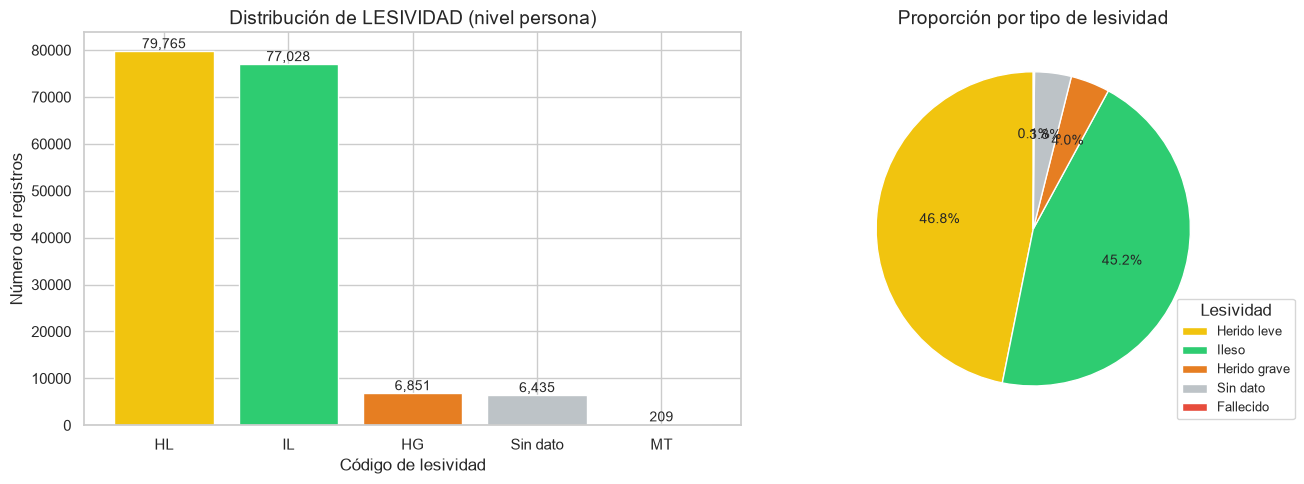

In [12]:
# Gráfico de distribución de LESIVIDAD
lesividad_plot = df['LESIVIDAD'].fillna('Sin dato')
lesividad_dist = lesividad_plot.value_counts()
order = lesividad_dist.index.tolist()
colores_orden = [COLORES_LESIVIDAD_EXT.get(c, COLOR_SIN_DATO) for c in order]
labels_map = {'IL': 'Ileso', 'HL': 'Herido leve', 'HG': 'Herido grave',
              'MT': 'Fallecido', 'Sin dato': 'Sin dato'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(order, lesividad_dist.values, color=colores_orden, edgecolor='white')
axes[0].set_title('Distribución de LESIVIDAD (nivel persona)', fontsize=14)
axes[0].set_xlabel('Código de lesividad')
axes[0].set_ylabel('Número de registros')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

labels_pie = [labels_map[c] for c in order]
wedges, _, _ = axes[1].pie(lesividad_dist.values, labels=None, autopct='%1.1f%%',
                            colors=colores_orden, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción por tipo de lesividad', fontsize=14)
axes[1].legend(wedges, labels_pie, title='Lesividad', loc='lower left',
               bbox_to_anchor=(0.85, 0), fontsize=9)

plt.tight_layout()
plt.savefig('../figures/01a_distribucion_lesividad.png', dpi=150)
plt.show()

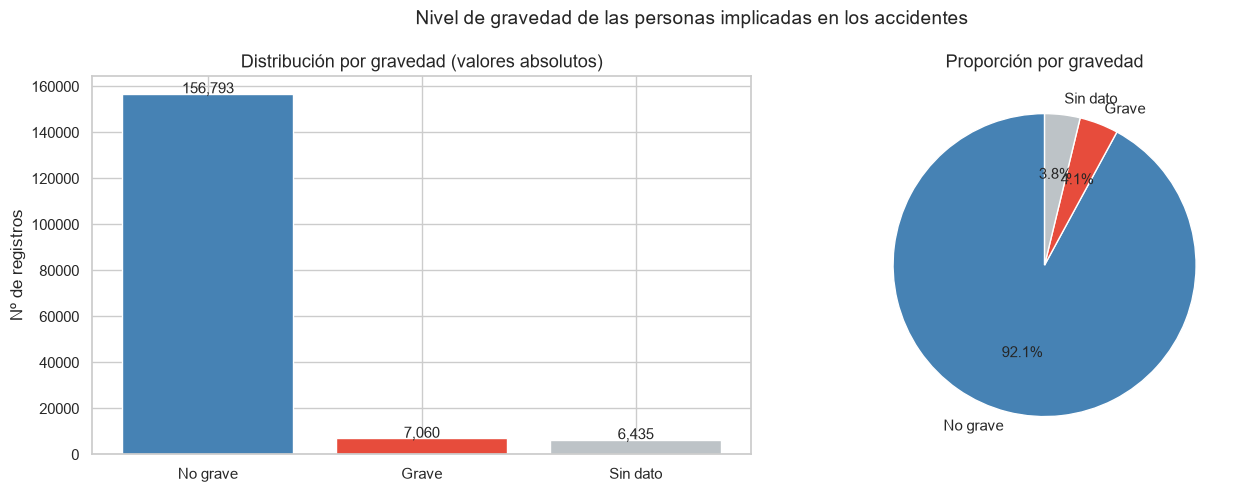

Desequilibrio de clases — ratio: 22.2:1
Graves + Fallecidos: 7,060 de 163,853 con lesividad conocida (4.31%)


In [13]:
# Clasificación binaria
gravedad_num = df['LESIVIDAD'].map({
    'IL': 0, 'HL': 0,
    'HG': 1, 'MT': 1
})  # NaN → Sin dato

gravedad_labels = gravedad_num.map(LABELS_GRAVE_EXT).fillna('Sin dato')
gravedad_counts = gravedad_labels.value_counts()

# Orden fijo: No grave → Grave → Sin dato
orden_grav = [LABELS_GRAVE_EXT[k] for k in [0, 1] if LABELS_GRAVE_EXT[k] in gravedad_counts.index]
if 'Sin dato' in gravedad_counts.index:
    orden_grav.append('Sin dato')
gravedad_counts = gravedad_counts.reindex(orden_grav)

colors_grav = [COLORES_GRAVE_EXT[k] for k in ([0, 1] + (['Sin dato'] if 'Sin dato' in gravedad_counts.index else []))]

# --- Desequilibrio de clases: ratio y % siempre sobre el mismo denominador
# (solo casos con LESIVIDAD conocida, excluyendo "Sin dato") ---
n_no_grave = gravedad_counts.get('No grave', 0)
n_grave    = gravedad_counts.get('Grave', 0)
n_conocidos = n_no_grave + n_grave  # excluye 'Sin dato' del denominador

ratio = n_no_grave / n_grave
pct_grave = n_grave / n_conocidos * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(gravedad_counts.index, gravedad_counts.values, color=colors_grav, edgecolor='white')
axes[0].set_title('Distribución por gravedad (valores absolutos)', fontsize=13)
axes[0].set_ylabel('Nº de registros')
for bar, val in zip(axes[0].patches, gravedad_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11)

axes[1].pie(gravedad_counts.values, labels=gravedad_counts.index,
            autopct='%1.1f%%', colors=colors_grav, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporción por gravedad', fontsize=13)

plt.suptitle('Nivel de gravedad de las personas implicadas en los accidentes', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/01b_gravedad_binaria.png', dpi=150)
plt.show()

print(f'Desequilibrio de clases — ratio: {ratio:.1f}:1')
print(f'Graves + Fallecidos: {n_grave:,} de {n_conocidos:,} con lesividad conocida '
      f'({pct_grave:.2f}%)')

### 📝 Resumen — Sección 2

> - La categoría más frecuente es HL (herido leve) con 80.869 registros (46,4%), seguida de IL (ileso) con 78.526 (45%).
> - Las personas con heridas graves o fallecidas representan el **4,3% del total**, lo que supone un notable **desequilibrio de clases** (ratio ~22.5:1) que deberá abordarse en la fase de modelización.
> - Se utilizará **clasificación binaria** una vez se hayan limpiado los datos: Accidente grave/Accidente leve, ya que el objetivo es predecir la probabilidad de consecuencias graves dadas las condiciones del accidente.

---
## 3. Perfil de los implicados

El perfil de las personas implicadas en el accidente (su rol, sexo, edad y tipo de vehículo) puede estar relacionado con la gravedad de las consecuencias. Se analiza la distribución de cada variable y su relación con `LESIVIDAD` a nivel persona.

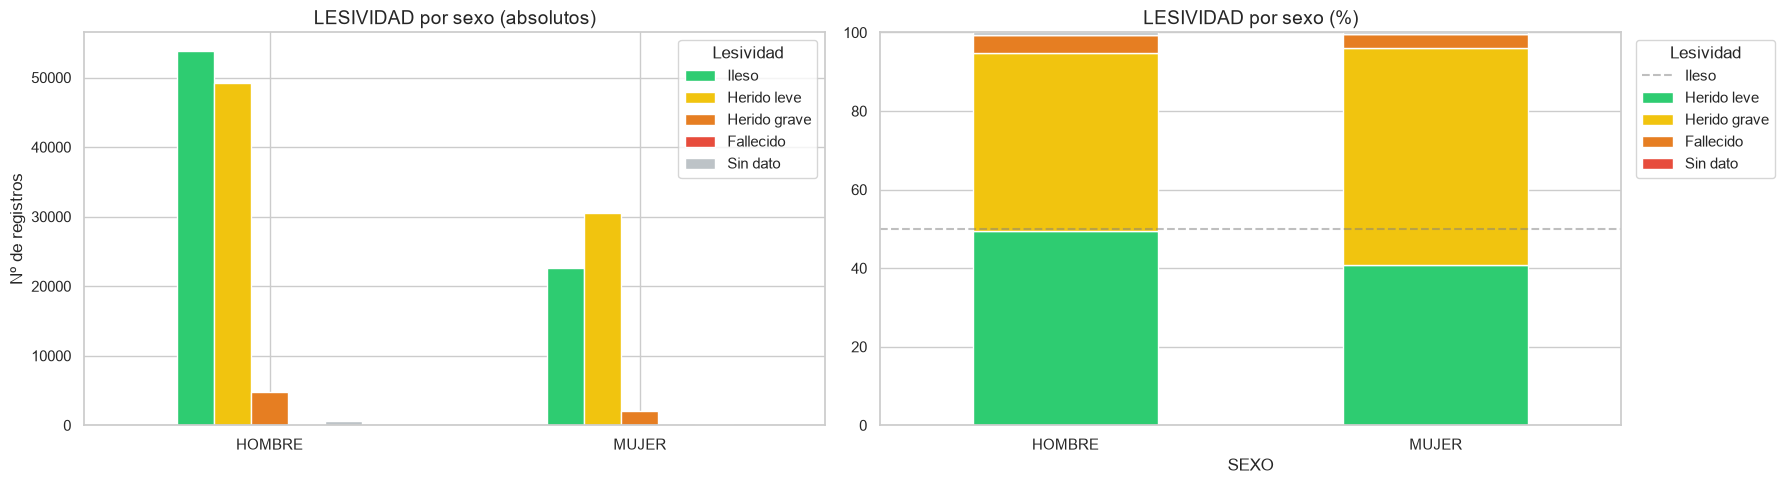

In [14]:
from src.utils.graficos import graficar_lesividad_categoria, graficar_lesividad_y_tasa_grave

df_sexo = df[df['SEXO'].isin(['HOMBRE', 'MUJER'])].copy()
tabla, tabla_pct = graficar_lesividad_categoria(
    df_sexo, 'SEXO', ORDEN_LESIVIDAD_EXT, COLORES_LESIVIDAD_EXT, LABELS_LESIVIDAD_EXT,
    titulo_base='LESIVIDAD por sexo', filename='../figures/03a_lesividad_por_sexo.png'
)

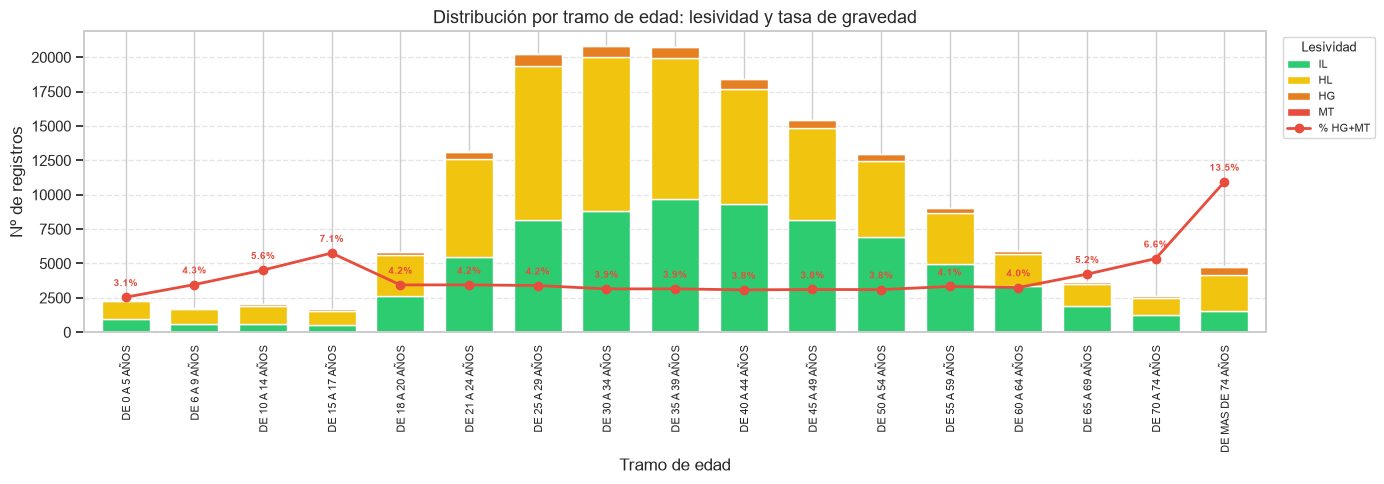

In [15]:
orden_edad = [
    'DE 0 A 5 AÑOS', 'DE 6 A 9 AÑOS', 'DE 10 A 14 AÑOS', 'DE 15 A 17 AÑOS',
    'DE 18 A 20 AÑOS', 'DE 21 A 24 AÑOS', 'DE 25 A 29 AÑOS', 'DE 30 A 34 AÑOS',
    'DE 35 A 39 AÑOS', 'DE 40 A 44 AÑOS', 'DE 45 A 49 AÑOS', 'DE 50 A 54 AÑOS',
    'DE 55 A 59 AÑOS', 'DE 60 A 64 AÑOS', 'DE 65 A 69 AÑOS', 'DE 70 A 74 AÑOS',
    'DE MAS DE 74 AÑOS'
]

lesividad_edad, tasa_grave_edad = graficar_lesividad_y_tasa_grave(
    df_sin_na, 'Tramo Edad', ORDEN_LESIVIDAD, COLORES_LESIVIDAD,
    orden_categorias=orden_edad,
    titulo='Distribución por tramo de edad: lesividad y tasa de gravedad',
    xlabel='Tramo de edad', rotation=90,
    filename='../figures/03b_distribucion_tramo_edad.png', figsize=(14, 5)
)

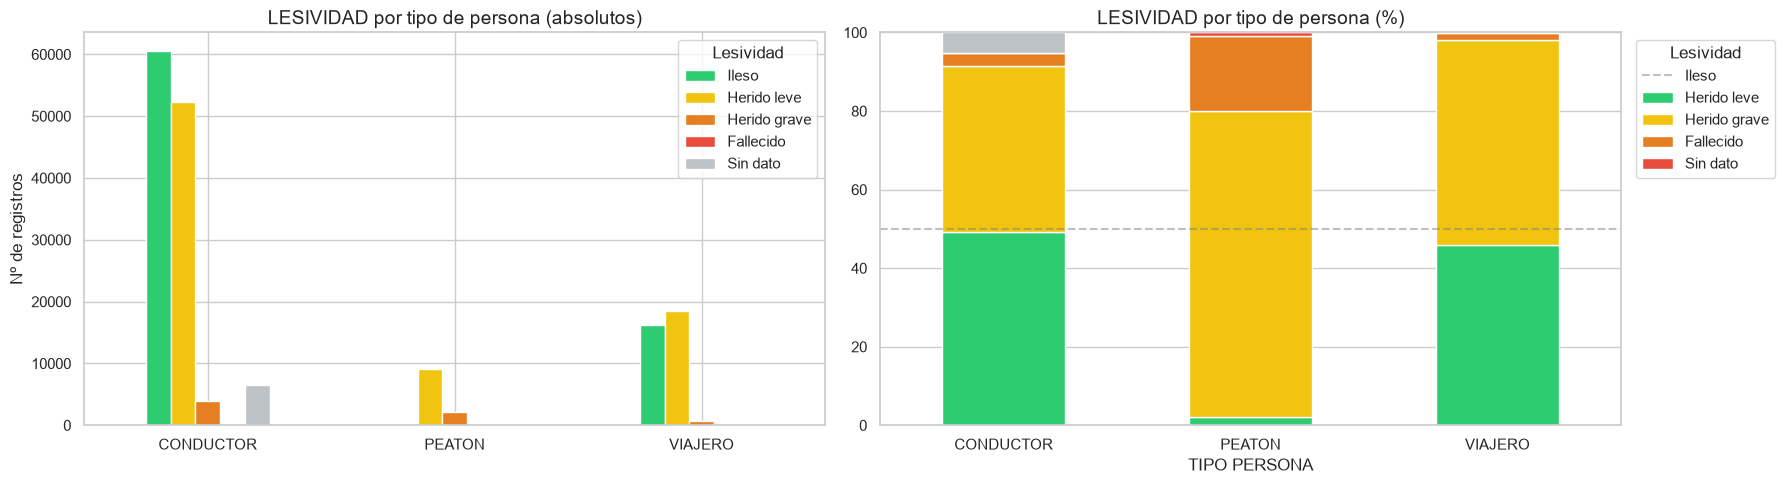

In [16]:
tabla, tabla_pct = graficar_lesividad_categoria(
    df, 'TIPO PERSONA', ORDEN_LESIVIDAD_EXT, COLORES_LESIVIDAD_EXT, LABELS_LESIVIDAD_EXT,
    titulo_base='LESIVIDAD por tipo de persona',
    filename='../figures/03c_lesividad_por_tipo_persona.png'
)

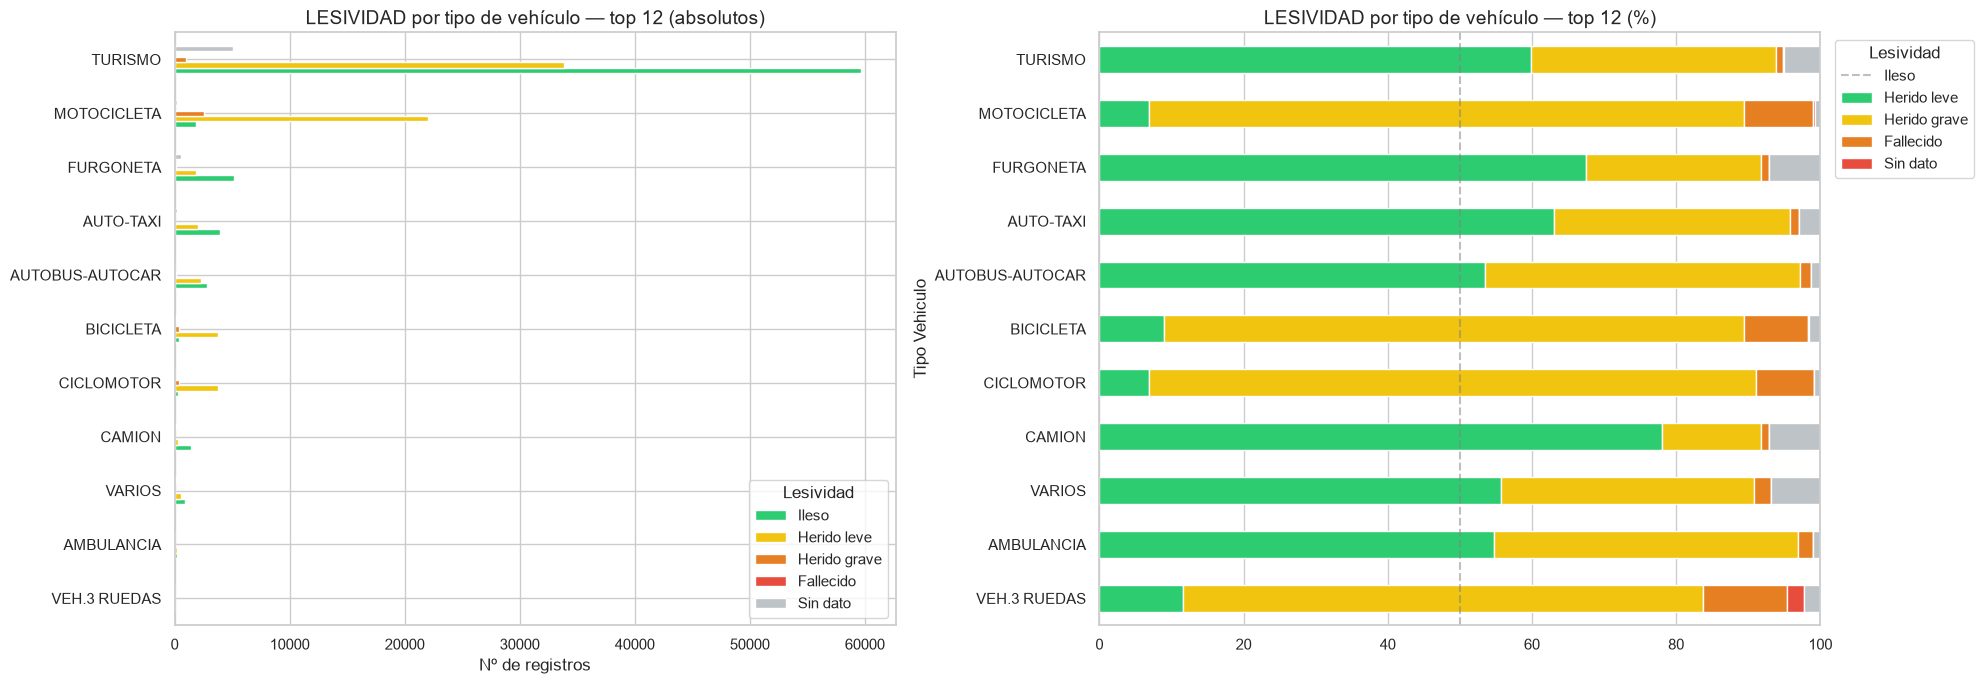

In [17]:
df_veh_all = df.dropna(subset=['Tipo Vehiculo']).copy()
top_vehiculos = df_veh_all['Tipo Vehiculo'].value_counts().head(12).index
df_veh_top = df_veh_all[df_veh_all['Tipo Vehiculo'].isin(top_vehiculos)]

tabla, tabla_pct = graficar_lesividad_categoria(
    df_veh_top, 'Tipo Vehiculo', ORDEN_LESIVIDAD_EXT, COLORES_LESIVIDAD_EXT, LABELS_LESIVIDAD_EXT,
    titulo_base='LESIVIDAD por tipo de vehículo — top 12', horizontal=True, ordenar_por_total=True,
    filename='../figures/13_lesividad_por_vehiculo.png', figsize=(20, 7)
)

In [18]:
# ¿La falta de Tipo Vehiculo (~18% del dataset a nivel persona) es aleatoria
# o sigue un patrón, igual que se comprobó antes para LESIVIDAD (Sección 2)?
pct_sin_vehiculo = (df.assign(sin_vehiculo=df['Tipo Vehiculo'].isna())
                      .groupby('TIPO PERSONA')['sin_vehiculo'].mean() * 100)
print('% sin Tipo Vehiculo asignado, por tipo de persona:')
print(pct_sin_vehiculo.round(2).to_string())


% sin Tipo Vehiculo asignado, por tipo de persona:
TIPO PERSONA
CONDUCTOR     0.00
PEATON       99.94
VIAJERO       0.21


**Nota sobre `Tipo Vehiculo` sin asignar (~18% del dataset a nivel persona)**

A diferencia de `LESIVIDAD`, esta falta de dato no es un problema de calidad: es
estructural. El resultado de arriba muestra que prácticamente el 100% de los peatones
no tienen `Tipo Vehiculo` asignado — lógico, ya que un peatón no conduce ningún
vehículo — mientras que conductores y viajeros tienen el dato casi completo. Por tanto
no se trata como una limitación del dato ni requiere imputación: basta con excluir los
`NaN` al analizar esta variable, como ya se hace en el gráfico anterior.


### 📝 Resumen — Sección 3

> - El tipo de persona más frecuente son los **conductores**, seguidos de viajeros y peatones. Los **peatones presentan la mayor proporción de heridos graves y fallecidos**, lo que los convierte en el grupo más vulnerable.
> - Los **hombres** representan un mayor volumen de accidentalidad que las mujeres. En términos de gravedad relativa, ambos sexos presentan proporciones similares, aunque los hombres muestran una tasa de HG+MT ligeramente superior.
> - Los tramos de edad con mayor gravedad relativa son los **mayores de 65 años** y los **menores de 18 años**, reflejando mayor vulnerabilidad física en edades extremas. Los tramos de 25-44 años concentran el mayor volumen de accidentes por ser los conductores más activos.
> - Los vehículos con mayor tasa de lesividad grave son las **motocicletas y bicicletas**, mientras que los turismos concentran el mayor volumen absoluto.

---
## 4. Conclusiones y paso siguiente

> - El dataset contiene registros a nivel persona con fuerte desequilibrio de clases (~4% graves).  
> - Los **peatones**, **mayores de 65** y usuarios de **motocicleta/bicicleta** son los perfiles más vulnerables.  
> - Los hombres representan mayor volumen de accidentalidad pero ambos sexos tienen gravedad relativa similar.  

El siguiente paso es **agregar el dataset a nivel accidente** y realizar el EDA orientado al modelo.

---
# EDA II: Análisis a nivel accidente

---
## 5. Transformación: de nivel persona a nivel accidente

Dado que el objetivo del trabajo es predecir la gravedad del **accidente** (no la de los implicados), se transforma el dataset desde una estructura a nivel persona a una estructura a nivel accidente.

Para ello se agregan los registros por identificador de accidente (`Nº PARTE`) y se define la **variable objetivo** como la máxima lesividad registrada entre todos sus implicados:

- `accidente_grave = 1` si algún implicado resultó herido grave o fallecido
- `accidente_grave = 0` en caso contrario (ilesos y heridos leves)

Las variables contextuales del accidente (fecha, distrito, tipo de vía, condiciones meteorológicas...) se toman de la primera fila de cada grupo, ya que son idénticas para todos los implicados de un mismo accidente.

In [19]:
GRAVES = ['HG', 'MT']

# Variables del accidente (iguales para todos los implicados del mismo accidente)
vars_accidente = [
    'FECHA', 'AÑO', 'MES', 'DIA SEMANA', 'RANGO HORARIO',
    'DISTRITO', 'LUGAR ACCIDENTE', 'TIPO ACCIDENTE',
    'Nº VICTIMAS *',
    *[c for c in df.columns if c.startswith('CPFA') or c.startswith('CPSV')]
]

df_accidentes = (
    df_sin_na.groupby('Nº PARTE')
    .agg(
        **{var: (var, 'first') for var in vars_accidente if var in df_sin_na.columns},
        accidente_grave=('LESIVIDAD', lambda x: int(x.isin(GRAVES).any())),
        n_implicados=('LESIVIDAD', 'count'),
    )
    .reset_index()
)

print(f'Accidentes únicos: {len(df_accidentes):,}')
print(f'\nDistribución de accidente_grave:')
print(df_accidentes['accidente_grave'].value_counts())
pct_grave_persona = df_sin_na['LESIVIDAD'].isin(['HG','MT']).mean()*100
ratio_persona = (100 - pct_grave_persona) / pct_grave_persona
print(f"  Ratio a nivel persona  : ~{ratio_persona:.1f}:1  (cualquier lesión leve vs HG+MT)")

Accidentes únicos: 68,773

Distribución de accidente_grave:
accidente_grave
0    62169
1     6604
Name: count, dtype: int64
  Ratio a nivel persona  : ~22.2:1  (cualquier lesión leve vs HG+MT)


### 5.2 Análisis de desbalanceo de clases

El desequilibrio entre clases se analiza a continuación antes de pasar a la modelización.

In [20]:
# ── Desbalanceo a nivel accidente ─────────────────────────────────────────────
n_total   = len(df_accidentes)
n_graves  = df_accidentes["accidente_grave"].sum()
n_no_grav = n_total - n_graves
ratio     = n_no_grav / n_graves
acc_naive = n_no_grav / n_total  # clasificador que predice siempre "no grave"

print("── Distribución de clases (nivel accidente) ──────────────────────────")
print(f"  No grave  (0): {n_no_grav:>6,}  ({n_no_grav/n_total*100:.1f}%)")
print(f"  Grave     (1): {n_graves:>6,}  ({n_graves/n_total*100:.1f}%)")
print(f"  Ratio 0:1    : {ratio:.1f}:1")
print()
print("── Baseline naïve ────────────────────────────────────────────────────")
print(f"  Un clasificador que predice siempre 'no grave' obtiene:")
print(f"  Accuracy = {acc_naive*100:.1f}%  —  esta es la referencia mínima a superar.")
print()
print("── Transición de niveles ─────────────────────────────────────────────")
print(f"  Ratio a nivel persona  : ~22.5:1  (cualquier lesión leve vs HG+MT)")
print(f"  Ratio a nivel accidente: ~{ratio:.1f}:1   (tras agregar por máximo de lesividad)")
print(f"  La agregación reduce el desequilibrio porque un accidente con")
print(f"  víctimas mixtas (p.ej. un HG + varios IL) queda clasificado como grave.")

── Distribución de clases (nivel accidente) ──────────────────────────
  No grave  (0): 62,169  (90.4%)
  Grave     (1):  6,604  (9.6%)
  Ratio 0:1    : 9.4:1

── Baseline naïve ────────────────────────────────────────────────────
  Un clasificador que predice siempre 'no grave' obtiene:
  Accuracy = 90.4%  —  esta es la referencia mínima a superar.

── Transición de niveles ─────────────────────────────────────────────
  Ratio a nivel persona  : ~22.5:1  (cualquier lesión leve vs HG+MT)
  Ratio a nivel accidente: ~9.4:1   (tras agregar por máximo de lesividad)
  La agregación reduce el desequilibrio porque un accidente con
  víctimas mixtas (p.ej. un HG + varios IL) queda clasificado como grave.


In [21]:
# ── Verificación del impacto real de LESIVIDAD desconocida a nivel accidente ──
df['LESIVIDAD_NA'] = df['LESIVIDAD'].isna()

# 1. ¿Se pierde algún accidente de CHOQUE CON OBJETO FIJO por completo?
choque_objeto = df[df['TIPO ACCIDENTE'] == 'CHOQUE CON OBJETO FIJO']
n_choque_objeto = choque_objeto['Nº PARTE'].nunique()
perdidos_choque = choque_objeto.groupby('Nº PARTE')['LESIVIDAD_NA'].all().sum()
print(f'Accidentes de tipo CHOQUE CON OBJETO FIJO: {n_choque_objeto:,}')
print(f'  ...perdidos por completo (todas las personas sin LESIVIDAD): {perdidos_choque}')

# 2. ¿Se pierde algún accidente por completo en TODO el dataset?
perdidos_total = df.groupby('Nº PARTE')['LESIVIDAD_NA'].all().sum()
print(f'\nAccidentes perdidos por completo (dataset completo): {perdidos_total}')

# 3. Riesgo residual: accidentes con AL MENOS una persona de LESIVIDAD
#    desconocida (el accidente se conserva, pero GRAVE podría estar
#    infravalorado si esa persona era la más gravemente herida)
n_afectados = df.groupby('Nº PARTE')['LESIVIDAD_NA'].any().sum()
n_total = df['Nº PARTE'].nunique()
pct_afectado = n_afectados / n_total * 100
print(f'\nAccidentes con AL MENOS una persona de LESIVIDAD desconocida: '
      f'{n_afectados:,} de {n_total:,} ({pct_afectado:.2f}%)')

Accidentes de tipo CHOQUE CON OBJETO FIJO: 4,041
  ...perdidos por completo (todas las personas sin LESIVIDAD): 0

Accidentes perdidos por completo (dataset completo): 0



Accidentes con AL MENOS una persona de LESIVIDAD desconocida: 6,090 de 68,773 (8.86%)


#### Impacto real de la falta de LESIVIDAD tras agregar a nivel accidente

El análisis anterior mostró que, a nivel persona, la falta de `LESIVIDAD` no es aleatoria y se concentra en `CHOQUE CON OBJETO FIJO` y `CAÍDA VEHÍCULO 3 RUEDAS`. Sin embargo, el target del modelo (`GRAVE`) no se construye a nivel persona, sino a **nivel accidente**, como el máximo de las lesividades conocidas entre todos los implicados — y esto amortigua buena parte del problema.

**Comprobación:** de los 4.041 accidentes de tipo `CHOQUE CON OBJETO FIJO`, **ninguno se pierde por completo** — todos conservan al menos una persona con `LESIVIDAD` conocida, por lo que ningún accidente queda sin clasificar. Esto es válido para el conjunto completo de 68.773 accidentes: no se descarta ningún accidente por esta causa.

Sí existe un riesgo más sutil, y menor: **6.090 de esos 68.773 aacidentes** tienen al menos una persona con `LESIVIDAD` desconocida, aunque el accidente se conserve gracias a que otra persona sí la tiene. Si en alguno de esos casos la persona con el dato ausente era en realidad la más gravemente herida, el valor de `GRAVE` calculado podría **infravalorar** la gravedad real de ese accidente concreto.

> - Ningún accidente se pierde del dataset final por falta de `LESIVIDAD` — el impacto de este problema de calidad del dato es mucho menor de lo que sugería el análisis a nivel persona.
> - El riesgo residual (subestimación de `GRAVE`) afecta como mucho a un ~1.7% del dataset final, concentrado en `CHOQUE CON OBJETO FIJO`, y no tiene forma honesta de corregirse sin inventar datos.
> - **Limitación:** la tasa de gravedad estimada para accidentes de tipo `CHOQUE CON OBJETO FIJO` podría estar ligeramente subestimada respecto a la realidad, debido a la mayor tasa de datos de lesividad no asignados en este tipo concreto de accidente.

In [22]:
# Validación cruzada independiente: Nº VICTIMAS * (declarado a nivel
# accidente) vs nº de heridos/fallecidos realmente contados a partir de
# LESIVIDAD (HL + HG + MT) al agregar por Nº PARTE. Sirve para contrastar,
# con datos, la magnitud del riesgo residual estimado justo arriba.
victimas_contadas = (df_sin_na[df_sin_na['LESIVIDAD'].isin(['HL', 'HG', 'MT'])]
                      .groupby('Nº PARTE').size())
victimas_declaradas = df_sin_na.groupby('Nº PARTE')['Nº VICTIMAS *'].first()

comparacion = pd.concat(
    [victimas_contadas.rename('contadas'), victimas_declaradas.rename('declaradas')], axis=1
).fillna(0)
descuadre = comparacion['contadas'] != comparacion['declaradas']
declarado_mayor = descuadre & (comparacion['declaradas'] > comparacion['contadas'])

print(f'Accidentes comparados:                              {len(comparacion):>7,}')
print(f'Descuadres (declaradas != contadas):                {descuadre.sum():>7,} ({descuadre.mean()*100:.2f}%)')
print(f'  de ellos, declaradas > contadas (LESIVIDAD "perdida"): {declarado_mayor.sum():>4,} ({declarado_mayor.sum()/descuadre.sum()*100:.1f}% de los descuadres)')


Accidentes comparados:                               68,773
Descuadres (declaradas != contadas):                    993 (1.44%)
  de ellos, declaradas > contadas (LESIVIDAD "perdida"):  993 (100.0% de los descuadres)


**Interpretación de la validación cruzada anterior**

El porcentaje de descuadres es del mismo orden que el ~1.7% de riesgo residual estimado
arriba, y en la gran mayoría de los casos donde no coinciden, `Nº VICTIMAS *` declara
más víctimas de las que se pueden contar a partir de `LESIVIDAD`. Esto es consistente con
la hipótesis ya planteada: los descuadres se explican principalmente por personas con
`LESIVIDAD` no asignada que sí eran víctimas (heridas), no por un error de captura de
naturaleza distinta. No cambia ninguna decisión tomada hasta ahora, pero confirma con un
segundo método independiente que el problema de calidad de dato es pequeño y ya está
acotado.


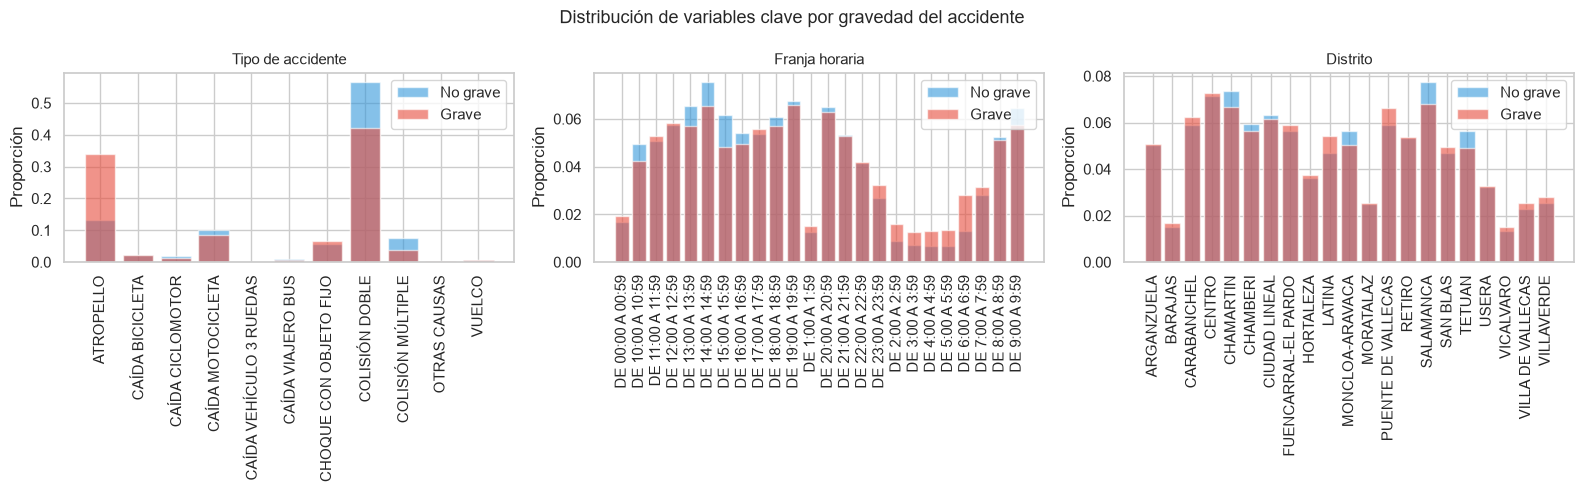

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribución de variables clave por gravedad del accidente", fontsize=13)

vars_plot = ["TIPO ACCIDENTE", "RANGO HORARIO", "DISTRITO"]
labels    = ["Tipo de accidente", "Franja horaria", "Distrito"]

for ax, var, label in zip(axes, vars_plot, labels):
    for clase, color, nombre in [(0, "#3498db", "No grave"), (1, "#e74c3c", "Grave")]:
        subset = (df_accidentes[df_accidentes["accidente_grave"] == clase]
                  [var].value_counts(normalize=True).sort_index())
        ax.bar(subset.index, subset.values,
               alpha=0.6, color=color, label=nombre, edgecolor="white")
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("Proporción")
    ax.tick_params(axis="x", rotation=90)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/05a_desbalanceo_clases.png", dpi=150, bbox_inches="tight")
plt.show()

El gráfico muestra que las clases **no se solapan uniformemente** en todas las variables:

- **Tipo de accidente** es la variable con mayor poder discriminante. Los atropellos
  tienen una proporción de graves muy superior a su peso en el total, mientras que
  las colisiones dobles (categoría dominante en volumen) presentan una tasa de
  gravedad mucho menor. Esto sugiere que el tipo de accidente será un predictor
  relevante en el modelo.

- **Franja horaria** muestra distribuciones casi paralelas entre clases, con una
  ligera sobrerrepresentación de accidentes graves en las franjas nocturnas
  (00:00–05:00), coherente con mayor velocidad y menor visibilidad. El poder
  discriminante es moderado.

- **Distrito** apenas diferencia entre clases — las barras son casi idénticas en
  proporción para todos los distritos. El distrito explica el volumen de accidentes
  pero no su gravedad, lo que sugiere que su utilidad como predictor será limitada
  o nula en el modelo.

En conjunto, el desbalanceo no implica que las clases sean inseparables: al menos
una variable (tipo de accidente) muestra diferencias claras de distribución que el
modelo podrá explotar.

### Estrategias para abordar el desequilibrio en la fase de modelización

El ratio ~9:1 es moderado pero suficiente para que un modelo naive ignore la clase
minoritaria. Se plantean tres estrategias complementarias, que se implementarán en
la fase de preprocesamiento y entrenamiento:

- **`class_weight='balanced'`** en los modelos que lo soporten (LogisticRegression,
  RandomForest, XGBoost) — penaliza los errores en la clase minoritaria sin alterar
  los datos.
- **SMOTE** (*Synthetic Minority Oversampling Technique*) — genera muestras sintéticas
  de accidentes graves para equilibrar el conjunto de entrenamiento.
- **Ajuste del umbral de decisión** — en lugar del umbral por defecto (0.5), se
  optimizará el umbral sobre la curva PR para maximizar F1 o recall en la clase grave,
  según el criterio de negocio (coste de un falso negativo vs falso positivo).

La métrica principal de evaluación **no será accuracy** (engañosa con clases
desbalanceadas) sino **F1-score de la clase grave**, **AUC-PR** y **recall**.

---
## 6. Análisis univariante: Nº de víctimas por accidente

`Nº VICTIMAS *` es la única variable numérica del dataset. Recoge el número de víctimas (personas heridas, graves o fallecidas) por accidente. Al ser una variable a nivel accidente, el análisis se realiza directamente sobre `df_accidentes`.

Se analiza su distribución, estadísticos descriptivos, normalidad y su relación con la variable objetivo `accidente_grave`.

In [24]:
# Estadísticos descriptivos de Nº VICTIMAS *
victimas_serie = df_accidentes['Nº VICTIMAS *'].dropna()

desc = {
    'Recuento':             victimas_serie.count(),
    'Media':                victimas_serie.mean(),
    'Mediana':              victimas_serie.median(),
    'Moda':                 victimas_serie.mode()[0],
    'Desviación estándar':  victimas_serie.std(),
    'Varianza':             victimas_serie.var(),
    'Mínimo':               victimas_serie.min(),
    'Q1 (25%)':             victimas_serie.quantile(0.25),
    'Q3 (75%)':             victimas_serie.quantile(0.75),
    'IQR':                  victimas_serie.quantile(0.75) - victimas_serie.quantile(0.25),
    'Máximo':               victimas_serie.max(),
    'Asimetría (skewness)': victimas_serie.skew(),
    'Curtosis (kurtosis)':  victimas_serie.kurtosis(),
}

for k, v in desc.items():
    print(f'{k:<28}: {v:.4f}' if isinstance(v, float) else f'{k:<28}: {v}')

# Límites de outliers (criterio IQR)
iqr     = desc['IQR']
lim_inf = desc['Q1 (25%)'] - 1.5 * iqr
lim_sup = desc['Q3 (75%)'] + 1.5 * iqr
n_outliers = ((victimas_serie < lim_inf) | (victimas_serie > lim_sup)).sum()
print(f'\nLímite inferior outliers (IQR): {lim_inf:.2f}')
print(f'Límite superior outliers (IQR): {lim_sup:.2f}')
print(f'Accidentes con outliers:        {n_outliers:,} ({n_outliers/len(victimas_serie)*100:.2f}%)')

Recuento                    : 68773
Media                       : 1.2791
Mediana                     : 1.0000
Moda                        : 1
Desviación estándar         : 0.7213
Varianza                    : 0.5203
Mínimo                      : 1
Q1 (25%)                    : 1.0000
Q3 (75%)                    : 1.0000
IQR                         : 0.0000
Máximo                      : 19
Asimetría (skewness)        : 4.6835
Curtosis (kurtosis)         : 43.9921

Límite inferior outliers (IQR): 1.00
Límite superior outliers (IQR): 1.00
Accidentes con outliers:        13,035 (18.95%)


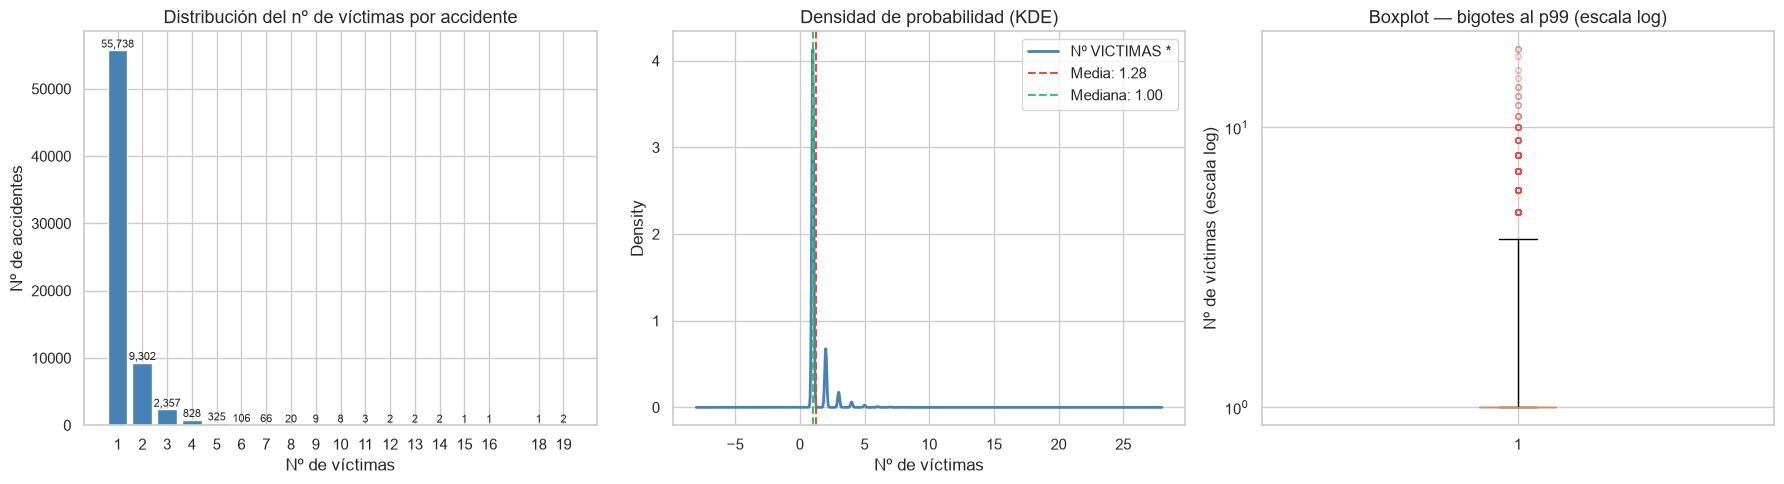

In [25]:
# Distribución: histograma, KDE y boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vc = victimas_serie.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
for x, y in zip(vc.index, vc.values):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', va='bottom', fontsize=8)
axes[0].set_title('Distribución del nº de víctimas por accidente', fontsize=13)
axes[0].set_xlabel('Nº de víctimas'); axes[0].set_ylabel('Nº de accidentes')
axes[0].set_xticks(vc.index)

victimas_serie.plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].axvline(victimas_serie.mean(),   color='#e74c3c', linestyle='--',
                label=f'Media: {victimas_serie.mean():.2f}')
axes[1].axvline(victimas_serie.median(), color='#2ecc71', linestyle='--',
                label=f'Mediana: {victimas_serie.median():.2f}')
axes[1].set_title('Densidad de probabilidad (KDE)', fontsize=13)
axes[1].set_xlabel('Nº de víctimas'); axes[1].legend()

# Boxplot con bigotes al percentil 99 (en vez del criterio IQR por defecto, que aquí
# es degenerado: IQR=0 marcaría cualquier valor >1 como outlier). Escala logarítmica
# para que los valores extremos no se amontonen todos en la parte superior del gráfico.
axes[2].boxplot(victimas_serie, vert=True, patch_artist=True, whis=(0, 99),
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='#e74c3c',
                                 alpha=0.4, markersize=4))
axes[2].set_yscale('log')
axes[2].set_title('Boxplot — bigotes al p99 (escala log)', fontsize=13)
axes[2].set_ylabel('Nº de víctimas (escala log)')

plt.tight_layout()
plt.savefig('../figures/06a_distribucion_victimas.png', dpi=150)
plt.show()

In [26]:
# Test de normalidad — Lilliefors (variante correcta del KS cuando los parámetros se estiman de la muestra)
# Nota: kstest(muestra, norm(loc=media, scale=std).cdf) es técnicamente incorrecto porque estimar los parámetros
# de la propia muestra sesga el test KS. El test de Lilliefors corrige esto.
from statsmodels.stats.diagnostic import lilliefors

n_muestra = min(5000, len(victimas_serie))
muestra   = victimas_serie.sample(n_muestra, random_state=42)

stat_ks, p_ks = lilliefors(muestra)

print(f'Test de Lilliefors (n={n_muestra:,}):')
print(f'  Estadístico KS = {stat_ks:.4f}')
print(f'  p-valor        = {p_ks:.4e}')
if p_ks < 0.05:
    print('  ✗ Se rechaza la hipótesis de normalidad (p < 0.05).')
    print('  → Distribución no normal: asimetría positiva / cola derecha.')
    print('  → Se usará Mann-Whitney U para comparar grupos (no paramétrico).')
else:
    print('  ✓ No se rechaza la hipótesis de normalidad.')

Test de Lilliefors (n=5,000):
  Estadístico KS = 0.4702
  p-valor        = 1.0000e-03
  ✗ Se rechaza la hipótesis de normalidad (p < 0.05).
  → Distribución no normal: asimetría positiva / cola derecha.
  → Se usará Mann-Whitney U para comparar grupos (no paramétrico).


Nota metodológica: se usa Lilliefors en lugar del test KS estándar porque KS asume que la distribución de referencia es independiente de los datos. Al estimar loc y scale de la propia muestra, el estadístico queda sesgado a la baja y el p-valor inflado. Lilliefors corrige esto recalibrando los valores críticos para el caso de parámetros estimados. La conclusión no cambia (p << 0.001), pero el procedimiento queda formalmente correcto.

Confirmada la falta de normalidad con el test de Lilliefors anterior, tampoco tendría sentido apoyarse en una regla que asume distribución normal sin más comprobación. Además, puesto que el 71,9% de los accidentes tienen 1 víctima, tanto Q1 como Q3 valen 1, por lo que el IQR es 0 y cualquier valor que no sea 1 sería considerado outlier con el criterio habitual. A continuación aplicamos el método 3σ para analizar la variable.

In [27]:
# Detección de outliers — regla de 3σ (IQR no aplicable: IQR = 0)
# Con Q1 = Q3 = 1, el criterio IQR convierte cualquier valor > 1 en "outlier" (no tiene sentido)
# Se usa media ± 3σ, más adecuado para variables de conteo con distribución concentrada

umbral_sup = victimas_serie.mean() + 3 * victimas_serie.std()
umbral_inf = max(victimas_serie.min(), victimas_serie.mean() - 3 * victimas_serie.std())

n_outliers = (victimas_serie > umbral_sup).sum()

print(f'Método IQR: IQR = 0 → no aplicable (Q1 = Q3 = {int(victimas_serie.quantile(0.25))})')
print(f'  Con IQR=0, los límites IQR serían ambos = 1.0, flaggeando el')
print(f'  {(victimas_serie > 1).mean()*100:.1f}% de los datos como "outliers" (falso positivo masivo)\n')

print(f'Método 3σ (aplicado):')
print(f'  Media ± 3σ = {victimas_serie.mean():.2f} ± 3×{victimas_serie.std():.2f}')
print(f'  Umbral superior: {umbral_sup:.2f}  →  se considera outlier si Nº VICTIMAS > {int(umbral_sup)}')
print(f'  Accidentes con outliers: {n_outliers:,} ({n_outliers/len(victimas_serie)*100:.2f}%)')
print(f'\nDistribución de valores extremos (>= {int(umbral_sup)+1} víctimas):')
print(victimas_serie[victimas_serie > umbral_sup].value_counts().sort_index().to_string())

Método IQR: IQR = 0 → no aplicable (Q1 = Q3 = 1)
  Con IQR=0, los límites IQR serían ambos = 1.0, flaggeando el
  19.0% de los datos como "outliers" (falso positivo masivo)

Método 3σ (aplicado):
  Media ± 3σ = 1.28 ± 3×0.72
  Umbral superior: 3.44  →  se considera outlier si Nº VICTIMAS > 3
  Accidentes con outliers: 1,376 (2.00%)

Distribución de valores extremos (>= 4 víctimas):
Nº VICTIMAS *
4     828
5     325
6     106
7      66
8      20
9       9
10      8
11      3
12      2
13      2
14      2
15      1
16      1
18      1
19      2


### ¿Es aplicable la regla de 3σ aquí? Comprobación y alternativa

No del todo: `Nº VICTIMAS *` tiene una asimetría (*skewness*) de **4.68** y una curtosis de **44** — muy lejos de una distribución normal. Bajo el supuesto de normalidad, el límite superior de media + 3σ debería dejar por debajo aproximadamente el 99.85% de los datos (en la cola superior); en la práctica, solo el **98.0%** de los accidentes caen por debajo de ese umbral — la cola real es más "pesada" de lo que asume el método. Además, la propia cola larga que se quiere detectar como atípica es la que infla la media y la desviación típica usadas para definir el umbral (un problema de circularidad).

Se aplica a continuación un criterio de **percentiles empíricos**, que no depende de ningún supuesto sobre la forma de la distribución — la alternativa recomendada para variables de conteo muy asimétricas como esta.

In [28]:
# --- Límites de outliers: percentiles empíricos (95% / 99%) ---
p95 = victimas_serie.quantile(0.95)
p99 = victimas_serie.quantile(0.99)

n_outliers_p95 = (victimas_serie > p95).sum()
n_outliers_p99 = (victimas_serie > p99).sum()

print(f'Percentil 95 (límite superior): {p95:.0f} víctimas')
print(f'  Accidentes por encima:        {n_outliers_p95:,} ({n_outliers_p95/len(victimas_serie)*100:.2f}%)')
print()
print(f'Percentil 99 (límite superior): {p99:.0f} víctimas')
print(f'  Accidentes por encima:        {n_outliers_p99:,} ({n_outliers_p99/len(victimas_serie)*100:.2f}%)')

Percentil 95 (límite superior): 3 víctimas
  Accidentes por encima:        1,376 (2.00%)

Percentil 99 (límite superior): 4 víctimas
  Accidentes por encima:        548 (0.80%)


In [29]:
# Test Mann-Whitney U: ¿difiere el nº de víctimas entre accidentes graves y no graves?
from scipy.stats import mannwhitneyu

graves    = df_accidentes.loc[df_accidentes['accidente_grave'] == 1, 'Nº VICTIMAS *'].dropna()
no_graves = df_accidentes.loc[df_accidentes['accidente_grave'] == 0, 'Nº VICTIMAS *'].dropna()

stat_mw, p_mw = mannwhitneyu(graves, no_graves, alternative='two-sided')

print('Test Mann-Whitney U — Nº VICTIMAS * entre accidentes graves y no graves:')
print(f'  Media graves:    {graves.mean():.3f}  |  Mediana: {graves.median():.1f}')
print(f'  Media no graves: {no_graves.mean():.3f}  |  Mediana: {no_graves.median():.1f}')
print(f'  Estadístico U  = {stat_mw:.0f}')
print(f'  p-valor        = {p_mw:.4e}')
print()
if p_mw < 0.05:
    print('  ✓ Diferencia estadísticamente significativa (p < 0.05).')
    print('  → Los accidentes graves tienden a tener más víctimas que los no graves.')
else:
    print('  ✗ No hay diferencia estadísticamente significativa.')

Test Mann-Whitney U — Nº VICTIMAS * entre accidentes graves y no graves:
  Media graves:    1.310  |  Mediana: 1.0
  Media no graves: 1.276  |  Mediana: 1.0
  Estadístico U  = 207833505
  p-valor        = 1.4733e-02

  ✓ Diferencia estadísticamente significativa (p < 0.05).
  → Los accidentes graves tienden a tener más víctimas que los no graves.


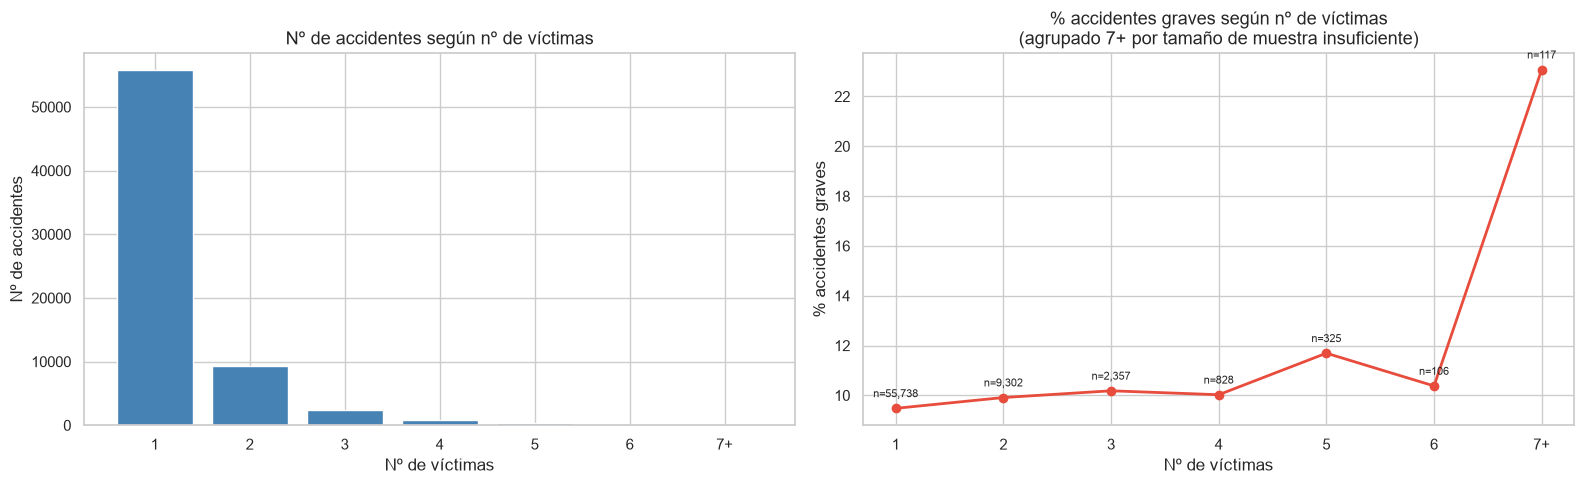

In [30]:
# Relación entre nº de víctimas y tasa de accidentes graves
# Se agrupan los valores >= 7 víctimas (muestra insuficiente: n < 100 por valor individual,
# lo que producía porcentajes muy inestables — ver comprobación en el texto anterior) en una
# única categoría "7+", para obtener una tasa estable en vez de ruido de muestra pequeña.
df_accidentes['victimas_agrupado'] = df_accidentes['Nº VICTIMAS *'].apply(lambda x: '7+' if x >= 7 else str(int(x)))
orden_victimas = [str(i) for i in range(1, 7)] + ['7+']

tasa_grave_vic = (df_accidentes.groupby('victimas_agrupado')['accidente_grave']
                               .agg(['mean', 'count'])
                               .rename(columns={'mean': 'pct_grave', 'count': 'n_accidentes'})
                               .assign(pct_grave=lambda x: x['pct_grave'] * 100)
                               .reindex(orden_victimas)
                               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(tasa_grave_vic['victimas_agrupado'], tasa_grave_vic['n_accidentes'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Nº de accidentes según nº de víctimas', fontsize=13)
axes[0].set_xlabel('Nº de víctimas'); axes[0].set_ylabel('Nº de accidentes')

axes[1].plot(tasa_grave_vic['victimas_agrupado'], tasa_grave_vic['pct_grave'],
             marker='o', color='#e74c3c', linewidth=2)
for x, y, n in zip(tasa_grave_vic['victimas_agrupado'], tasa_grave_vic['pct_grave'], tasa_grave_vic['n_accidentes']):
    axes[1].annotate(f'n={n:,}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
axes[1].set_title('% accidentes graves según nº de víctimas\n(agrupado 7+ por tamaño de muestra insuficiente)', fontsize=13)
axes[1].set_xlabel('Nº de víctimas'); axes[1].set_ylabel('% accidentes graves')

plt.tight_layout()
plt.savefig('../figures/06b_victimas_vs_gravedad.png', dpi=150)
plt.show()

> ⚠️ **Nota sobre `Nº VICTIMAS *` y data leakage**
>
> Aunque el análisis descriptivo muestra que los accidentes graves tienden a tener más víctimas,
> esta variable **no puede usarse como predictor en el modelo**. El número de víctimas es una
> **variable consecuencia**: solo se conoce *después* de que el accidente haya ocurrido y su
> gravedad ya sea un hecho. Incluirla como feature introduciría **data leakage**, ya que el modelo
> aprendería de información que no estaría disponible en el momento de la predicción.
>
> `Nº VICTIMAS *` se mantiene en el EDA con fines descriptivos para caracterizar el dataset,
> pero quedará **excluida de la fase de preprocesado y modelización**.

### 📝 Resumen — Sección 6

> - `Nº VICTIMAS *` presenta distribución **fuertemente asimétrica a la derecha**: la mayoría de accidentes tienen 1 víctima (71.9%).
> - El **test de Lilliefors rechaza la normalidad** (p << 0.05), lo que justifica el uso de tests no paramétricos y descarta la regla de 3σ como criterio principal de outliers (su supuesto de normalidad no se cumple: skewness = 4.68, curtosis = 44).
> - El criterio **IQR no es aplicable** (Q1 = Q3 = 1, IQR = 0); se adopta el criterio de **percentiles empíricos** como referencia principal para caracterizar valores extremos: al 95%, se consideran atípicos los accidentes con más de 3 víctimas (2.00%); al 99%, más de 4 víctimas (0.80%).
> - El **test Mann-Whitney U** confirma que los accidentes graves tienen significativamente más víctimas que los no graves (p << 0.05).
> - Se observa una **correlación positiva** entre número de víctimas y tasa de gravedad del accidente.
> - Los valores extremos (accidentes con muchas víctimas) son pocos pero tienden a ser los más graves — aun así, **no se eliminan** del dataset (ver nota de data leakage): son accidentes reales, no errores de captura, y además `Nº VICTIMAS *` queda excluida como predictor por ser una variable consecuencia del propio accidente.
> **Resumen `n_implicados`:** La gran mayoría de accidentes implica a 1-2 personas. Se analiza si el número de implicados se asocia con mayor gravedad (puede reflejar el tipo de colisión). `n_implicados` se considerará como feature adicional en el modelo.

---
## 7. Análisis temporal

Se analiza la distribución de accidentes por año, mes, día de la semana y franja horaria, y su relación con la variable objetivo `accidente_grave`.

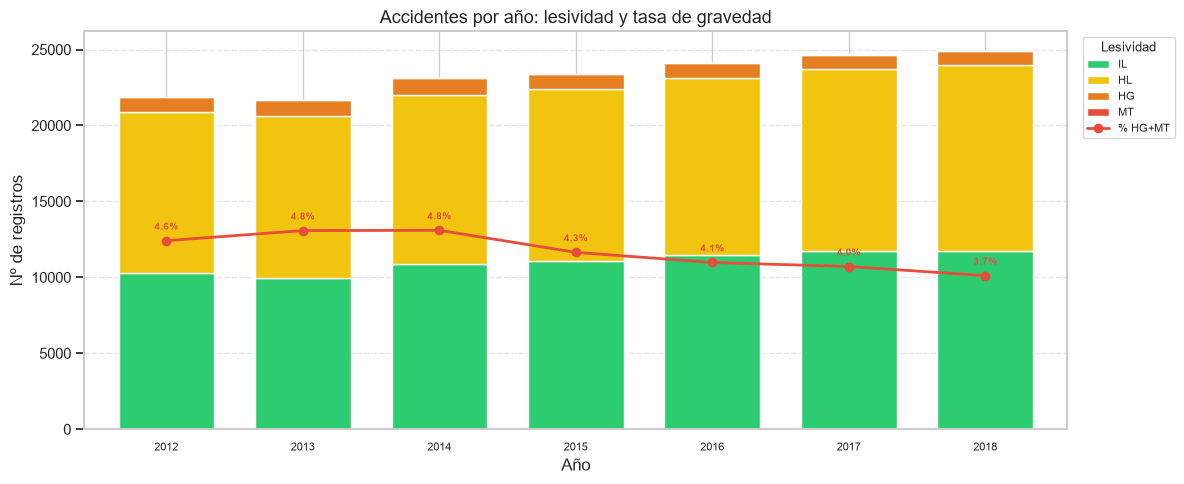

In [31]:
lesividad_año, tasa_grave_año = graficar_lesividad_y_tasa_grave(
    df_sin_na, 'AÑO', ORDEN_LESIVIDAD, COLORES_LESIVIDAD,
    titulo='Accidentes por año: lesividad y tasa de gravedad',
    xlabel='Año', filename='../figures/07a_accidentes_por_anio.png'
)

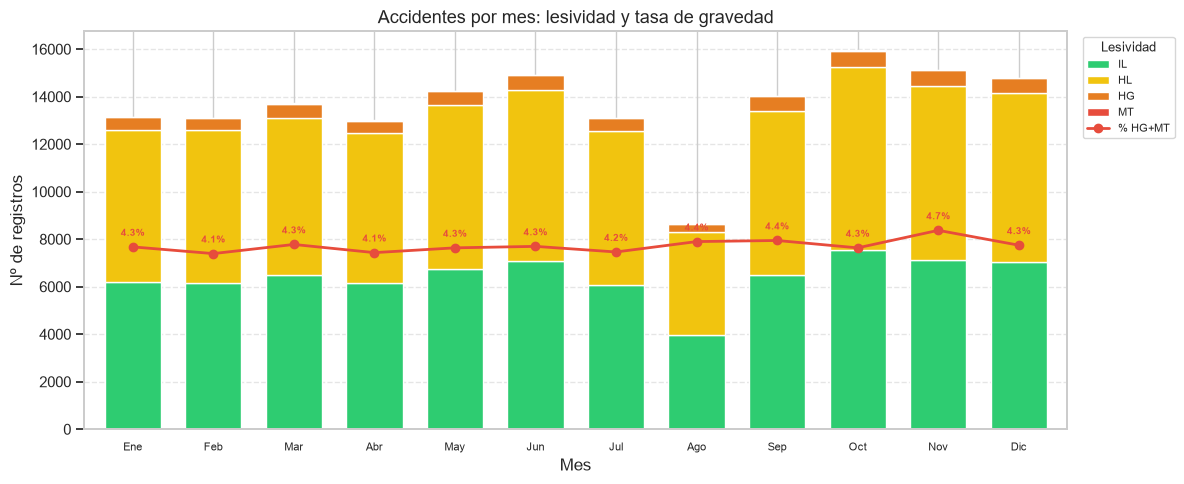

In [32]:
meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
         7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
df_sin_na['MES_NOMBRE'] = df_sin_na['MES'].map(meses)
orden_meses = [meses[m] for m in range(1, 13)]

lesividad_mes, tasa_grave_mes = graficar_lesividad_y_tasa_grave(
    df_sin_na, 'MES_NOMBRE', ORDEN_LESIVIDAD, COLORES_LESIVIDAD,
    orden_categorias=orden_meses,
    titulo='Accidentes por mes: lesividad y tasa de gravedad',
    xlabel='Mes', filename='../figures/07b_accidentes_por_mes.png'
)

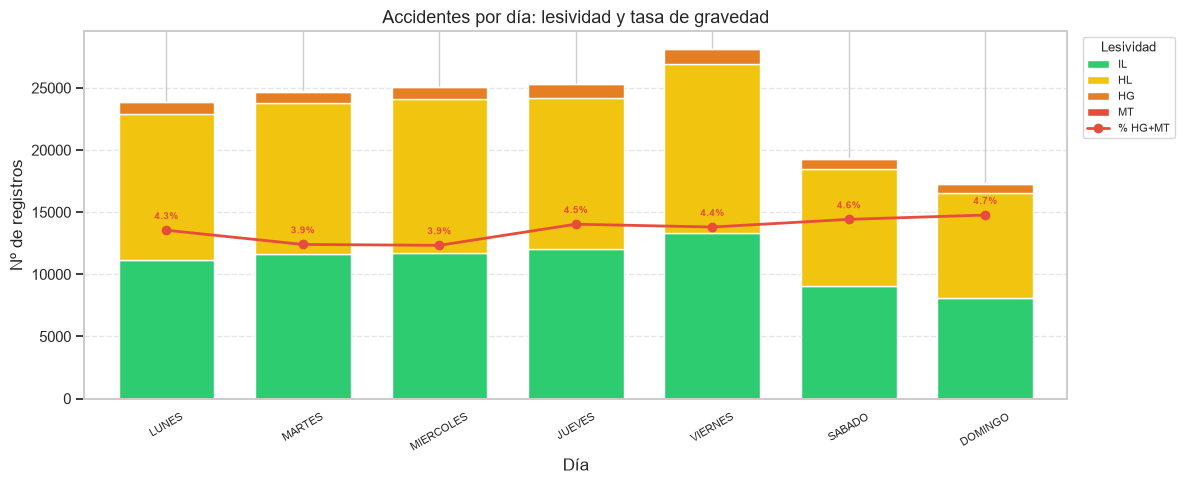

In [33]:
orden_dias = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']

lesividad_dia, tasa_grave_dia = graficar_lesividad_y_tasa_grave(
    df_sin_na, 'DIA SEMANA', ORDEN_LESIVIDAD, COLORES_LESIVIDAD,
    orden_categorias=orden_dias,
    titulo='Accidentes por día: lesividad y tasa de gravedad',
    xlabel='Día', rotation=30,
    filename='../figures/07c_accidentes_por_dia.png'
)

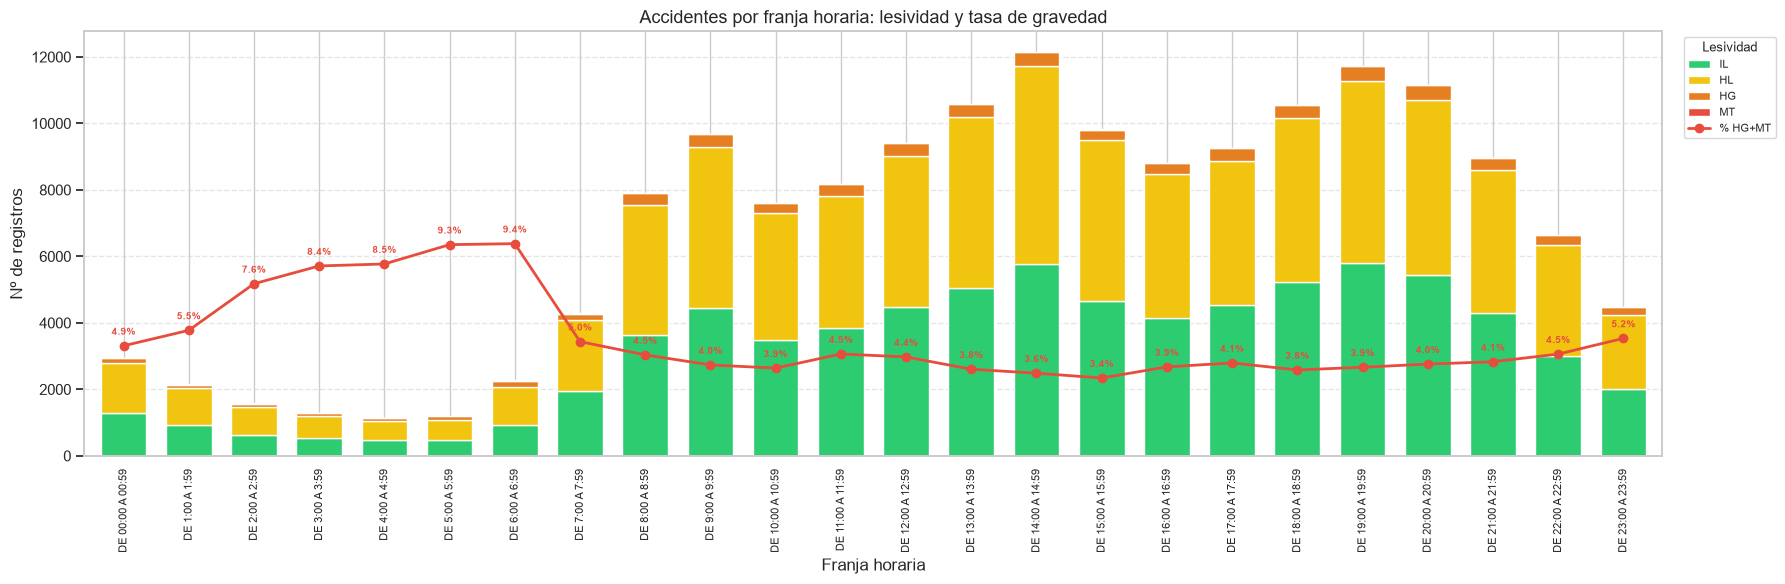

In [34]:
import re

orden_horas = sorted(df_sin_na['RANGO HORARIO'].dropna().unique(),
                      key=lambda x: int(re.search(r'(\d+)', x).group(1)))

lesividad_hora, tasa_grave_hora = graficar_lesividad_y_tasa_grave(
    df_sin_na, 'RANGO HORARIO', ORDEN_LESIVIDAD, COLORES_LESIVIDAD,
    orden_categorias=orden_horas,
    titulo='Accidentes por franja horaria: lesividad y tasa de gravedad',
    xlabel='Franja horaria', rotation=90,
    filename='../figures/07c_accidentes_por_hora.png', figsize=(18, 6)
)

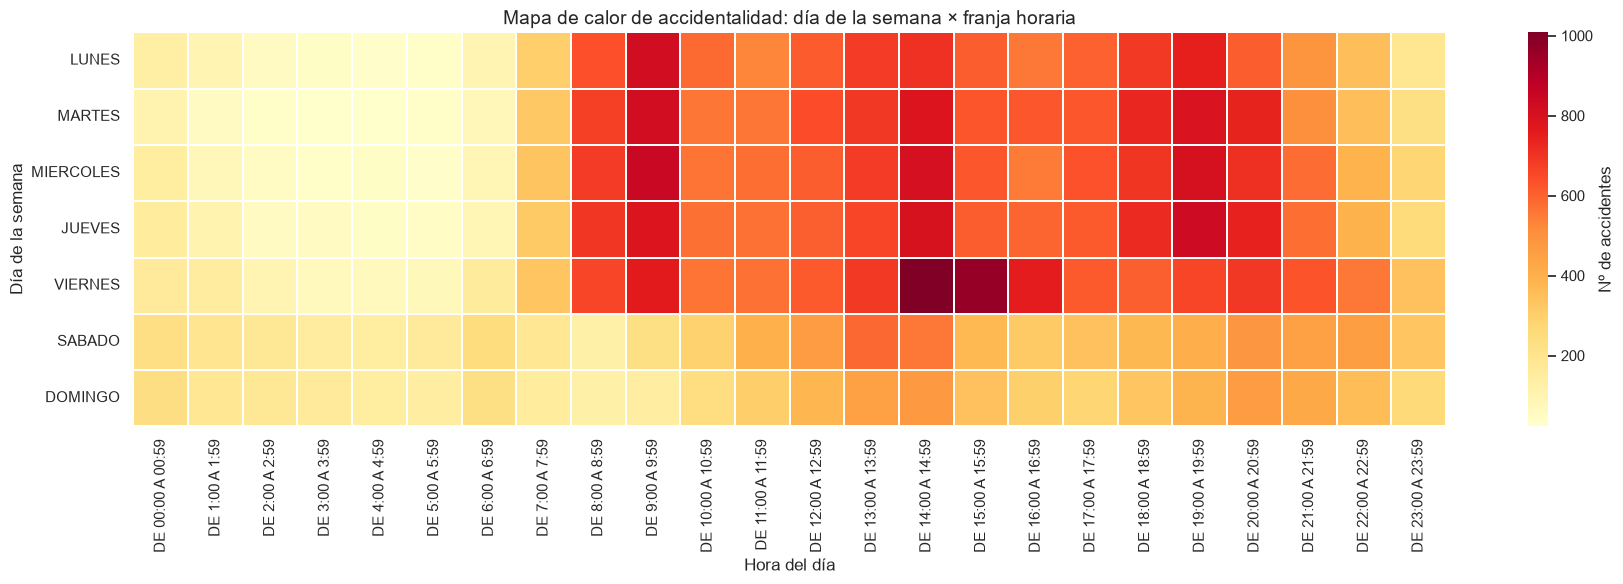

In [35]:
df_accidentes['HORA_NUM'] = df_accidentes['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)
mapa_etiquetas = (df_accidentes[['HORA_NUM', 'RANGO HORARIO']]
                  .drop_duplicates()
                  .sort_values('HORA_NUM')
                  .set_index('HORA_NUM')['RANGO HORARIO']
                  .to_dict())

heatmap_data = (df_accidentes.groupby(['DIA SEMANA', 'HORA_NUM'])
                      .size()
                      .unstack(fill_value=0)
                      .reindex(orden_dias, fill_value=0))
heatmap_data = heatmap_data.rename(columns=mapa_etiquetas)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Nº de accidentes'})
ax.set_title('Mapa de calor de accidentalidad: día de la semana × franja horaria', fontsize=14)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig('../figures/07d_heatmap_dia_hora.png', dpi=150, bbox_inches='tight')
plt.show()

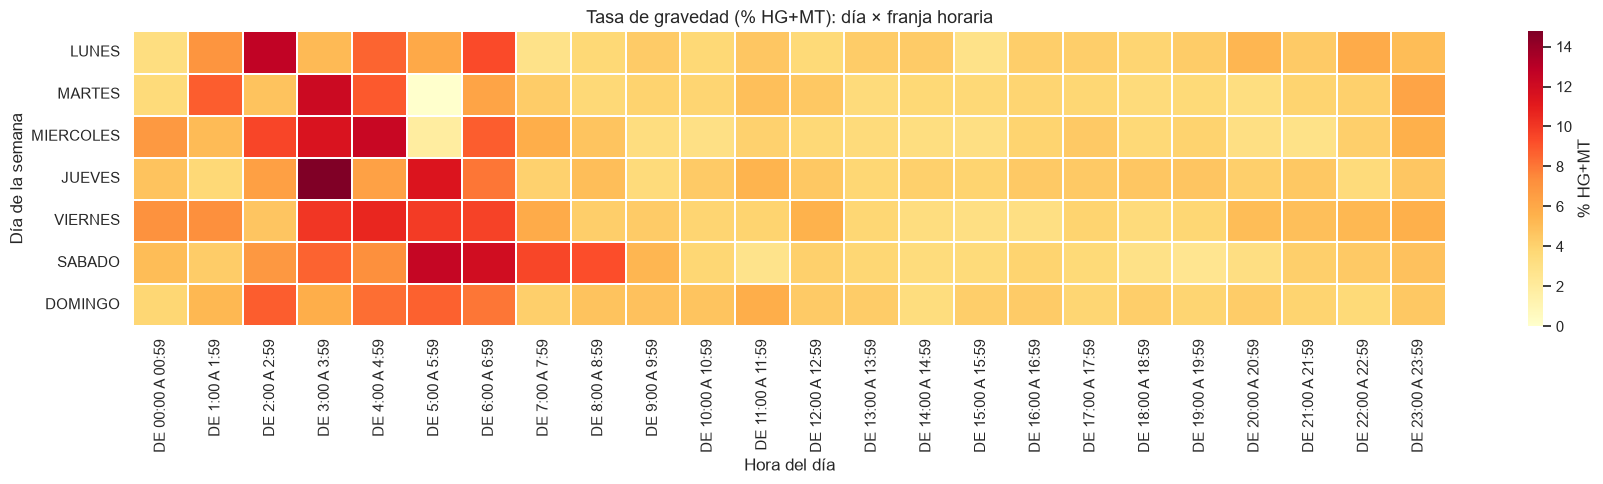

In [36]:
# DÍA SEMANA × FRANJA HORARIA — tasa de gravedad
df_sin_na['HORA_NUM'] = df_sin_na['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)
hm2 = (df_sin_na.groupby(['DIA SEMANA', 'HORA_NUM'])['GRAVE']
       .mean().unstack(fill_value=np.nan)
       .reindex(orden_dias, fill_value=np.nan) * 100)
hm2 = hm2.rename(columns=mapa_etiquetas)

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(hm2, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': '% HG+MT'}, annot=False)
ax.set_title('Tasa de gravedad (% HG+MT): día × franja horaria', fontsize=13)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig('../figures/07e_heatmap_gravedad_dia_hora.png', dpi=150, bbox_inches='tight')
plt.show()
df_sin_na.drop(columns=['HORA_NUM'], inplace=True, errors='ignore')

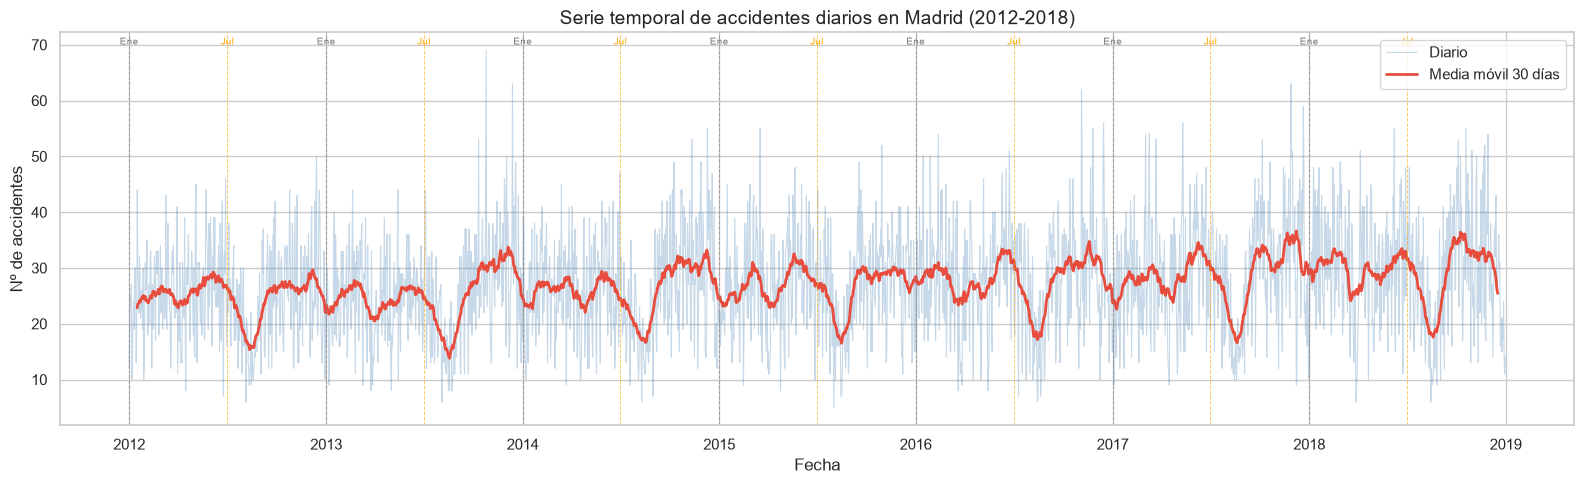

In [37]:
# Serie temporal: accidentes diarios con media móvil de 30 días
serie_temporal = (df_accidentes.groupby('FECHA').size().reset_index(name='Accidentes'))
serie_temporal['Media_30d'] = serie_temporal['Accidentes'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(serie_temporal['FECHA'], serie_temporal['Accidentes'],
        color='steelblue', alpha=0.3, linewidth=0.8, label='Diario')
ax.plot(serie_temporal['FECHA'], serie_temporal['Media_30d'],
        color='#e74c3c', linewidth=2, label='Media móvil 30 días')

for year in range(2012, 2019):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-07-01'), color='orange', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1]*0.97, 'Ene', fontsize=7, color='gray', ha='center')
    ax.text(pd.Timestamp(f'{year}-07-01'), ax.get_ylim()[1]*0.97, 'Jul', fontsize=7, color='orange', ha='center')

ax.set_title('Serie temporal de accidentes diarios en Madrid (2012-2018)', fontsize=14)
ax.set_xlabel('Fecha'); ax.set_ylabel('Nº de accidentes')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/07f_serie_temporal.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 7

> - Aunque el número de accidentes registrados va en aumento a lo largo de los años, la **proporción entre las diferentes clases de lesividad se mantiene estable**, lo que sugiere que la gravedad relativa no ha variado estructuralmente entre 2012 y 2018.
> - Los meses con mayor accidentalidad son **octubre, noviembre y junio**. Julio y agosto presentan la menor siniestralidad, probablemente por la reducción del tráfico en período vacacional.
> - Los días laborables concentran más accidentes que el fin de semana, coincidiendo con los desplazamientos al trabajo.
> - Las franjas horarias de mayor riesgo son las **horas punta** (9h, 14h, 17h). El heatmap confirma la concentración de accidentes en días laborables en esas franjas y destaca la alta siniestralidad del **viernes entre las 14h y las 16h**.
> - La serie temporal muestra una tendencia estructuralmente estable (entre 20 y 35 accidentes/día) con una **estacionalidad anual clara**: caída en verano y repunte en otoño.

---
## 8. Análisis geográfico

El distrito donde ocurre el accidente puede estar relacionado con factores estructurales como la densidad de tráfico, el tipo de vías o la velocidad permitida.

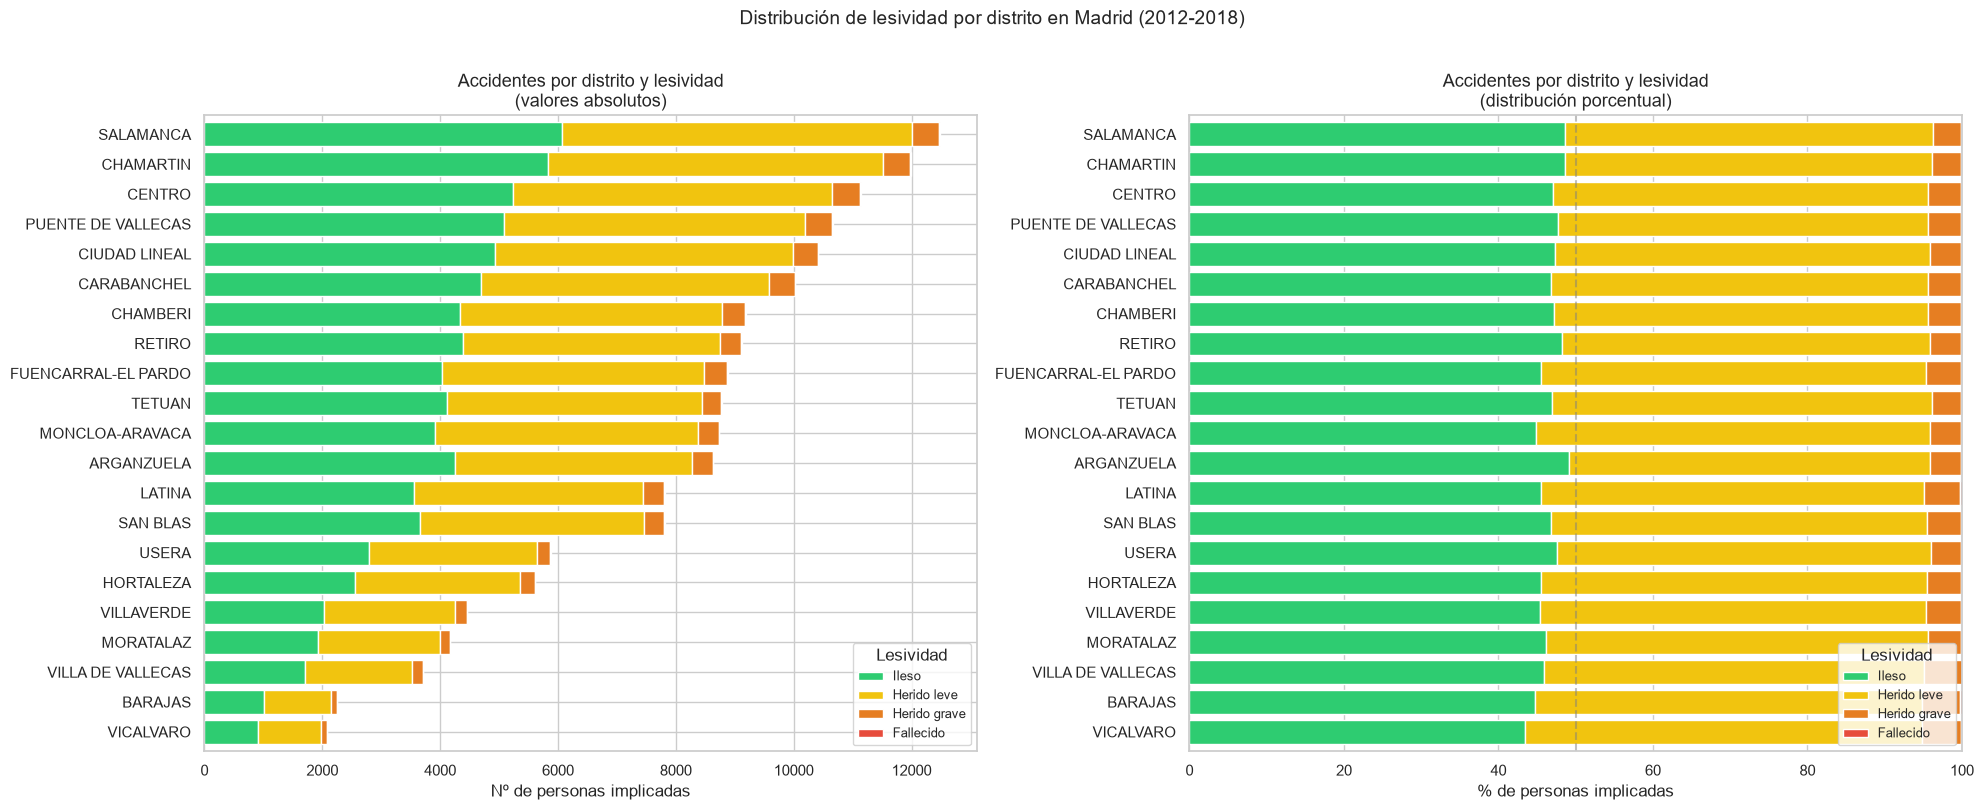

In [38]:
# Accidentes por distrito (nivel accidente)
accidentes_distrito = (df_accidentes.groupby('DISTRITO').size()
                             .sort_values(ascending=False)
                             .reset_index(name='Accidentes'))

# Lesividad apilada por distrito
lesividad_distrito = (df_sin_na.groupby(['DISTRITO', 'LESIVIDAD'])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_distrito['TOTAL'] = lesividad_distrito.sum(axis=1)
lesividad_distrito = lesividad_distrito.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_pct_dist = lesividad_distrito.div(lesividad_distrito.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

lesividad_distrito.plot(kind='barh', stacked=True, ax=axes[0],
                        color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], width=0.8)
axes[0].set_title('Accidentes por distrito y lesividad\n(valores absolutos)', fontsize=13)
axes[0].set_xlabel('Nº de personas implicadas'); axes[0].set_ylabel('')
axes[0].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               loc='lower right', fontsize=9)

lesividad_pct_dist.plot(kind='barh', stacked=True, ax=axes[1],
                         color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], width=0.8)
axes[1].set_title('Accidentes por distrito y lesividad\n(distribución porcentual)', fontsize=13)
axes[1].set_xlabel('% de personas implicadas'); axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)
axes[1].axvline(x=50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               loc='lower right', fontsize=9)

plt.suptitle('Distribución de lesividad por distrito en Madrid (2012-2018)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/08a_lesividad_por_distrito.png', dpi=150, bbox_inches='tight')
plt.show()

A continuación, se estudia si el número de accidentes tiene relación con la población media por distrito en Madrid durante el periodo estudiado.

In [39]:
# Población media por distrito (media aritmética 2012-2018)
# Fuente: Ayuntamiento de Madrid - Estadística padronal municipal.
# Tabla en data/raw/poblacion_distritos_madrid.csv (construida a partir de los
# datos padronales oficiales), en vez de un diccionario embebido en el notebook.
poblacion_df = pd.read_csv('../data/raw/poblacion_distritos_madrid.csv')
poblacion_distritos = poblacion_df.set_index('DISTRITO')['POBLACION_MEDIA_2012_2018'].to_dict()
N_AÑOS = 7

accidentes_distrito['Poblacion']        = accidentes_distrito['DISTRITO'].map(poblacion_distritos)
accidentes_distrito['Accidentes_anuales'] = accidentes_distrito['Accidentes'] / N_AÑOS
accidentes_distrito['Tasa_por_100k']    = (accidentes_distrito['Accidentes_anuales'] /
                                            accidentes_distrito['Poblacion'] * 100_000).round(1)
accidentes_distrito = accidentes_distrito.sort_values('Tasa_por_100k', ascending=False)
print(accidentes_distrito[['DISTRITO', 'Accidentes', 'Poblacion', 'Tasa_por_100k']].to_string(index=False))


           DISTRITO  Accidentes  Poblacion  Tasa_por_100k
             CENTRO        4931     134379          524.2
          SALAMANCA        5274     145977          516.1
          CHAMARTIN        5022     143899          498.6
    MONCLOA-ARAVACA        3845     116626          471.0
             RETIRO        3665     119387          438.5
           CHAMBERI        4071     138938          418.6
             TETUAN        3820     154592          353.0
         ARGANZUELA        3476     152309          326.0
            BARAJAS        1043      46918          317.6
           SAN BLAS        3229     156145          295.4
      CIUDAD LINEAL        4341     213941          289.9
          MORATALAZ        1725      94598          260.5
 PUENTE DE VALLECAS        4091     229315          254.9
        CARABANCHEL        4079     243663          239.1
              USERA        2227     136491          233.1
FUENCARRAL-EL PARDO        3884     238485          232.7
  VILLA DE VAL

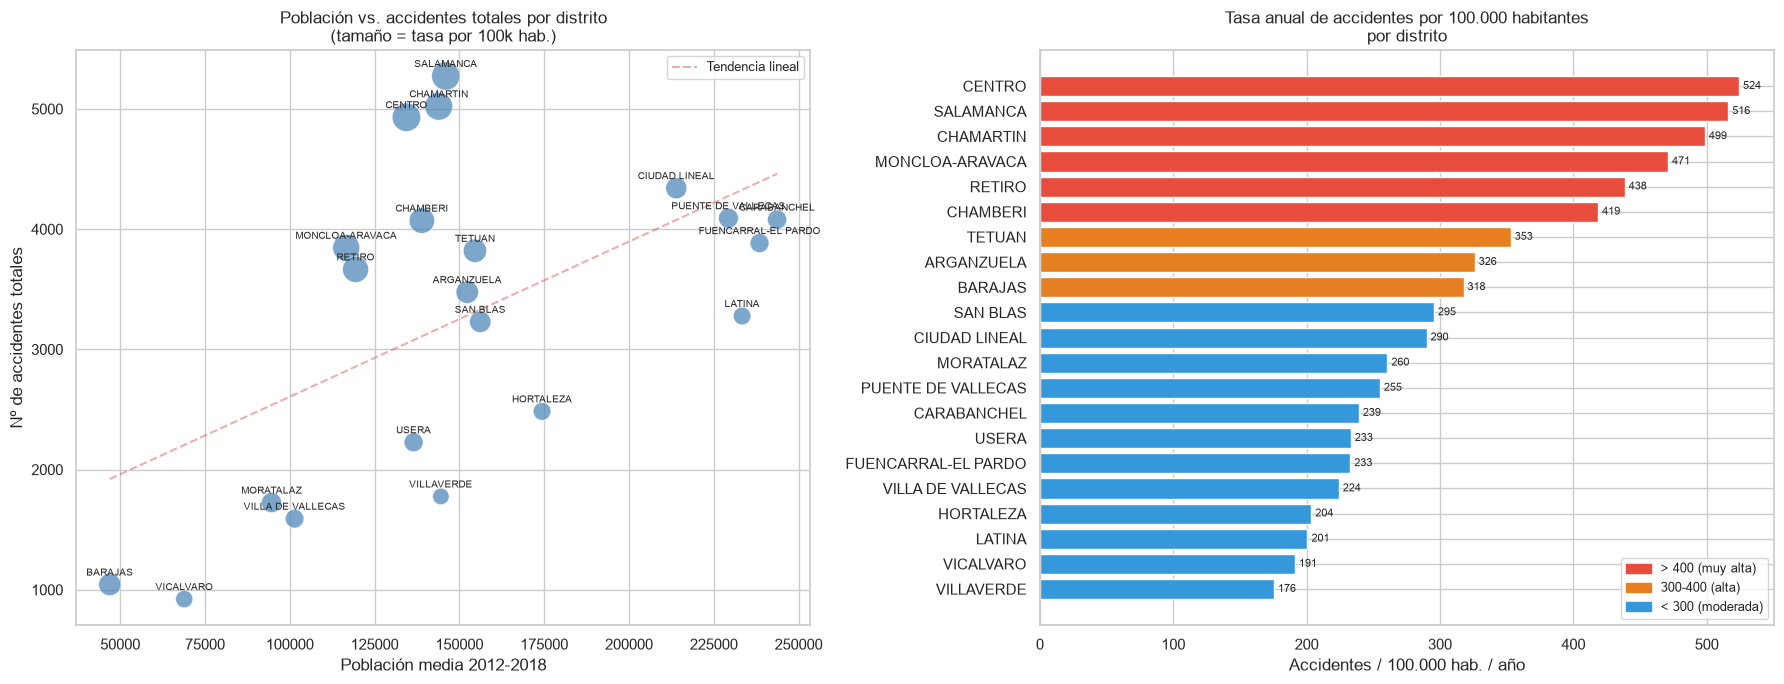

In [40]:
# Scatter: población vs accidentes + ranking por tasa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.scatter(accidentes_distrito['Poblacion'], accidentes_distrito['Accidentes'],
           s=accidentes_distrito['Tasa_por_100k'] * 0.8,
           alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
for _, row in accidentes_distrito.iterrows():
    ax.annotate(row['DISTRITO'], (row['Poblacion'], row['Accidentes']),
                fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
z = np.polyfit(accidentes_distrito['Poblacion'], accidentes_distrito['Accidentes'], 1)
p = np.poly1d(z)
x_line = np.linspace(accidentes_distrito['Poblacion'].min(), accidentes_distrito['Poblacion'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.5, label='Tendencia lineal')
ax.set_title('Población vs. accidentes totales por distrito\n(tamaño = tasa por 100k hab.)', fontsize=12)
ax.set_xlabel('Población media 2012-2018'); ax.set_ylabel('Nº de accidentes totales')
ax.legend(fontsize=9)

ax2 = axes[1]
datos_ordenados = accidentes_distrito.sort_values('Tasa_por_100k', ascending=True)
colores_tasa = ['#e74c3c' if t > 400 else '#e67e22' if t > 300 else '#3498db'
                for t in datos_ordenados['Tasa_por_100k']]
bars = ax2.barh(datos_ordenados['DISTRITO'], datos_ordenados['Tasa_por_100k'], color=colores_tasa)
ax2.set_title('Tasa anual de accidentes por 100.000 habitantes\npor distrito', fontsize=12)
ax2.set_xlabel('Accidentes / 100.000 hab. / año')
for bar, val in zip(bars, datos_ordenados['Tasa_por_100k']):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=8)
from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label='> 400 (muy alta)'),
           Patch(color='#e67e22', label='300-400 (alta)'),
           Patch(color='#3498db', label='< 300 (moderada)')]
ax2.legend(handles=leyenda, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/08b_scatter_poblacion_accidentes.png', dpi=150, bbox_inches='tight')
plt.show()

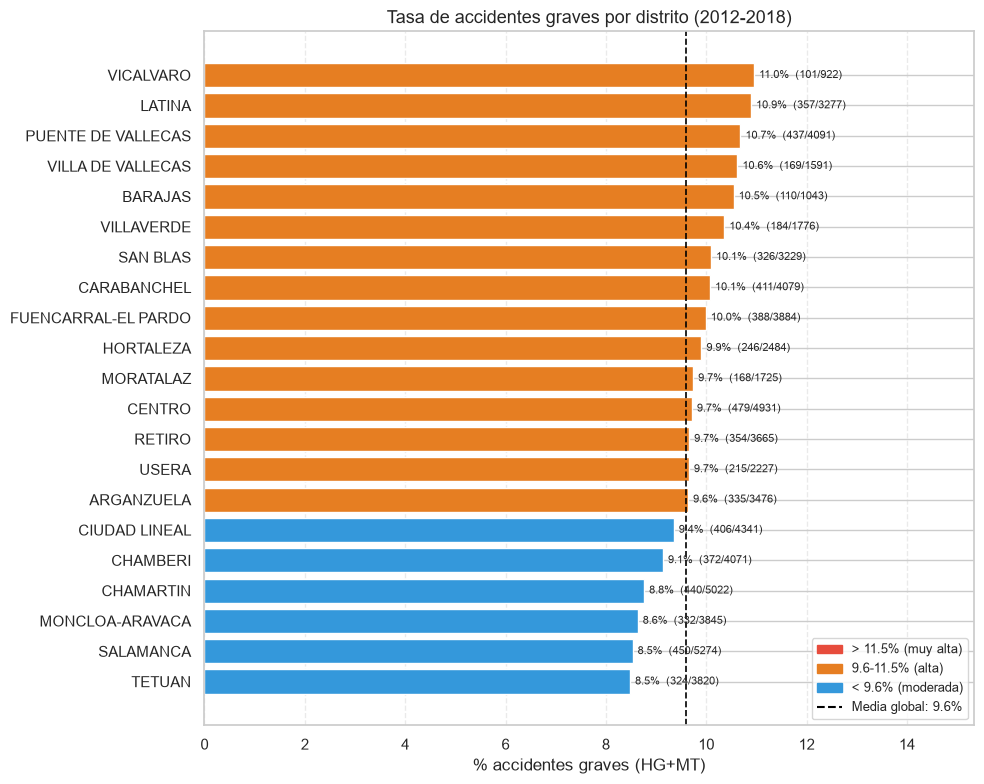

In [41]:
tasa_grave_dist = (df_accidentes.groupby('DISTRITO')['accidente_grave']
                   .agg(['mean', 'count', 'sum'])
                   .rename(columns={'mean': 'pct_grave', 'count': 'n_acc', 'sum': 'n_graves'})
                   .assign(pct_grave=lambda x: x['pct_grave'] * 100)
                   .sort_values('pct_grave', ascending=True))

media_global = df_accidentes['accidente_grave'].mean() * 100

colores = ['#e74c3c' if v > media_global * 1.2
           else '#e67e22' if v > media_global
           else '#3498db'
           for v in tasa_grave_dist['pct_grave']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(tasa_grave_dist.index, tasa_grave_dist['pct_grave'],
               color=colores, edgecolor='white')
ax.axvline(media_global, color='black', linestyle='--', linewidth=1.2,
           label=f'Media global: {media_global:.1f}%')
for bar, (_, row) in zip(bars, tasa_grave_dist.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{row['pct_grave']:.1f}%  ({int(row['n_graves'])}/{int(row['n_acc'])})",
            va='center', fontsize=8)

from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label=f'> {media_global*1.2:.1f}% (muy alta)'),
           Patch(color='#e67e22', label=f'{media_global:.1f}-{media_global*1.2:.1f}% (alta)'),
           Patch(color='#3498db', label=f'< {media_global:.1f}% (moderada)'),
           plt.Line2D([0], [0], color='black', linestyle='--', label=f'Media global: {media_global:.1f}%')]
ax.legend(handles=leyenda, fontsize=9, loc='lower right')
ax.set_title('Tasa de accidentes graves por distrito (2012-2018)', fontsize=13)
ax.set_xlabel('% accidentes graves (HG+MT)')
ax.set_xlim(0, tasa_grave_dist['pct_grave'].max() * 1.4)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../figures/08c_tasa_grave_distrito.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
import unicodedata
from pathlib import Path
import pandas as pd
import geopandas as gpd
import osmnx as ox

GEO_PATH = '../data/raw/distritos_madrid.gpkg'

# ── Distritos tal como aparecen en el dataset ─────────────────────────────────
DISTRITOS_DB = list(poblacion_distritos.keys())

# ── Función de normalización (quita acentos, mayúsculas) ─────────────────────
def normalizar(s):
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFD", str(s))
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return s.upper().strip()

MAPEO_ESPECIAL = {"SAN BLAS - CANILLEJAS": "SAN BLAS"}
distritos_norm = {normalizar(d): d for d in DISTRITOS_DB}

def match_distrito(nombre_osm):
    n = normalizar(nombre_osm)
    n = MAPEO_ESPECIAL.get(n, n)
    return distritos_norm.get(n)

# ── Carga con caché: solo llama a OSM si el archivo no existe ─────────────────
if Path(GEO_PATH).exists():
    gdf_21 = gpd.read_file(GEO_PATH)
    print(f"Geometrías cargadas desde caché: {GEO_PATH}")
else:
    print("Descargando geometrías desde OpenStreetMap...")
    place   = ox.geocode_to_gdf("Madrid, Community of Madrid, Spain")
    polygon = place.geometry.iloc[0]

    gdf_distritos = ox.features_from_polygon(
        polygon,
        tags={"boundary": "administrative", "admin_level": "9"}
    )
    gdf_distritos["DISTRITO"] = gdf_distritos["name"].apply(match_distrito)

    gdf_21 = (
        gdf_distritos[gdf_distritos["DISTRITO"].notna()]
        .drop_duplicates(subset="DISTRITO")
        [["geometry", "DISTRITO"]]
        .reset_index(drop=True)
    )

    gdf_21.to_file(GEO_PATH, driver="GPKG")
    print(f"Geometrías guardadas en caché: {GEO_PATH}")

print(f"Distritos encontrados: {len(gdf_21)}")
print(gdf_21[["DISTRITO"]])

Geometrías cargadas desde caché: ../data/raw/distritos_madrid.gpkg
Distritos encontrados: 21
               DISTRITO
0                 USERA
1            VILLAVERDE
2     VILLA DE VALLECAS
3    PUENTE DE VALLECAS
4             MORATALAZ
5              SAN BLAS
6             VICALVARO
7               BARAJAS
8             HORTALEZA
9           CARABANCHEL
10               LATINA
11      MONCLOA-ARAVACA
12               CENTRO
13  FUENCARRAL-EL PARDO
14           ARGANZUELA
15               RETIRO
16            SALAMANCA
17            CHAMARTIN
18               TETUAN
19             CHAMBERI
20        CIUDAD LINEAL


In [43]:
import folium
import pandas as pd

# ── 1. Contar ACCIDENTES únicos por distrito (no personas) ───────────────────
accidentes_por_distrito = (
    df.drop_duplicates(subset='Nº PARTE')
    .groupby("DISTRITO")
    .size()
    .reset_index(name="num_accidentes")
)

# ── 2. Merge con geometrías ────────────────────────────────────────────────────
gdf_mapa = gdf_21.merge(accidentes_por_distrito, on="DISTRITO", how="left")
gdf_mapa = gdf_mapa.to_crs(epsg=4326)
geo_json = gdf_mapa.__geo_interface__  # se calcula una vez y se reutiliza abajo

# ── 3. Mapa base centrado en Madrid ───────────────────────────────────────────
m = folium.Map(location=[40.4168, -3.7038], zoom_start=11, tiles="CartoDB positron")

# ── 4. Choropleth ──────────────────────────────────────────────────────────────
folium.Choropleth(
    geo_data=geo_json,
    data=accidentes_por_distrito,
    columns=["DISTRITO", "num_accidentes"],
    key_on="feature.properties.DISTRITO",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.5,
    legend_name="Nº de accidentes",
    nan_fill_color="lightgrey",
).add_to(m)

# ── 5. Tooltips con nombre y número al pasar el ratón ─────────────────────────
folium.GeoJson(
    geo_json,
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["DISTRITO", "num_accidentes"],
        aliases=["Distrito:", "Accidentes:"],
        localize=True,
        sticky=False,
    ),
).add_to(m)

# ── 6. Guardar ─────────────────────────────────────────────────────────────────
m.save('../figures/08d_mapa_gravedad_distritos.html')
print("Mapa guardado en ../figures/08d_mapa_gravedad_distritos.html")

Mapa guardado en ../figures/08d_mapa_gravedad_distritos.html


In [44]:
df_accidentes_copy = df_accidentes.copy()

gravedad_por_distrito = (
    df_accidentes_copy.groupby("DISTRITO")["accidente_grave"]
    .agg(total="count", graves="sum")
    .assign(pct_graves=lambda x: (x["graves"] / x["total"] * 100).round(1))
    .reset_index()
)

gdf_gravedad = gdf_21.merge(gravedad_por_distrito, on="DISTRITO", how="left").to_crs(epsg=4326)

# ── Mapa ───────────────────────────────────────────────────────────────────────
m2 = folium.Map(location=[40.4168, -3.7038], zoom_start=11, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=gdf_gravedad.__geo_interface__,
    data=gravedad_por_distrito,
    columns=["DISTRITO", "pct_graves"],
    key_on="feature.properties.DISTRITO",
    fill_color="RdPu",
    fill_opacity=0.75,
    line_opacity=0.5,
    legend_name="% accidentes graves o mortales (HG + MT)",
    nan_fill_color="lightgrey",
).add_to(m2)

folium.GeoJson(
    gdf_gravedad.__geo_interface__,
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["DISTRITO", "total", "graves", "pct_graves"],
        aliases=["Distrito:", "Total accidentes:", "Graves/Fallecidos:", "% gravedad:"],
    ),
).add_to(m2)

# nombre de archivo distinto al del mapa de volumen (08d), para no sobrescribirlo
m2.save('../figures/08e_mapa_gravedad_distritos.html')
print("Mapa guardado en ../figures/08e_mapa_gravedad_distritos.html")

Mapa guardado en ../figures/08e_mapa_gravedad_distritos.html


### 📝 Resumen — Sección 8

> - Una población más alta no se traduce directamente en más accidentes. **Salamanca, Chamartín y Centro** lideran en accidentalidad (tasa >490 accidentes/100k hab/año) sin ser los más poblados, lo que apunta al **tráfico de paso** como factor determinante.
> - Distritos periféricos con alta población (Latina, Carabanchel, Fuencarral) presentan tasas moderadas (<300).
> - Los distritos con mayor proporción de heridos graves o fallecidos (Villa de Vallecas, Vicálvaro, Barajas) **no coinciden** con los de mayor accidentalidad absoluta, lo que sugiere que el tipo de vía (carreteras de alta velocidad en periferia) influye más en la gravedad que el volumen.

---
## 9. Condiciones del accidente

Se analizan las variables relacionadas con el contexto del accidente: tipo, lugar, condiciones meteorológicas y estado del firme. Estas variables son candidatas clave para el modelo.

### Lugar del accidente

Se analiza brevemente el tipo de lugar o vía en que se producen los accidentes y su relación con la gravedad.

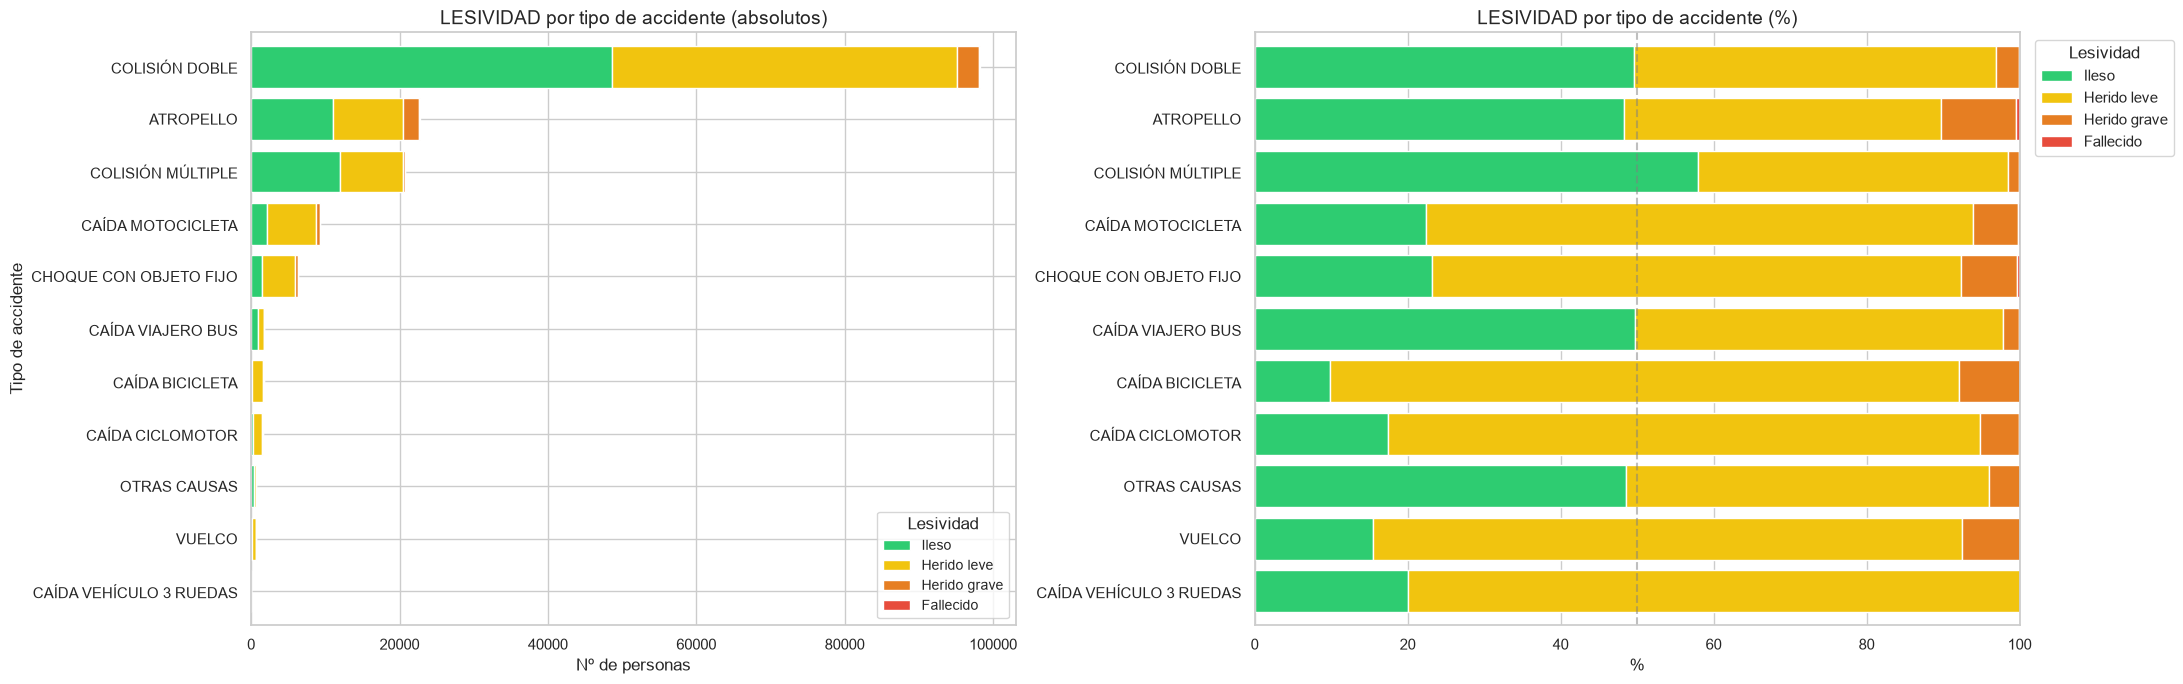

In [45]:
# Tipo de accidente (nivel accidente)
tipo_accidente = (df_accidentes.groupby('TIPO ACCIDENTE').size()
                        .sort_values(ascending=False)
                        .reset_index(name='Accidentes'))
tipo_accidente['Porcentaje (%)'] = (tipo_accidente['Accidentes'] / tipo_accidente['Accidentes'].sum() * 100).round(2)

# Tipo de accidente — absolutos apilados por lesividad + distribución %
lesividad_tipo_acc = (df_sin_na.groupby(['TIPO ACCIDENTE', 'LESIVIDAD'])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_tipo_acc['TOTAL'] = lesividad_tipo_acc.sum(axis=1)
lesividad_tipo_acc = lesividad_tipo_acc.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_tipo_acc_pct = lesividad_tipo_acc.div(lesividad_tipo_acc.sum(axis=1), axis=0) * 100

# Mismo orden para ambos gráficos
orden = lesividad_tipo_acc.index.tolist()

colores = [COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD]
labels  = ['Ileso', 'Herido leve', 'Herido grave', 'Fallecido']

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

lesividad_tipo_acc.reindex(orden).plot(kind='barh', stacked=True, ax=axes[0],
                                       color=colores, width=0.8, edgecolor='white')
axes[0].set_title('LESIVIDAD por tipo de accidente (absolutos)', fontsize=14)
axes[0].set_xlabel('Nº de personas'); axes[0].set_ylabel('Tipo de accidente')
axes[0].legend(title='Lesividad', labels=labels, loc='lower right', fontsize=10)

lesividad_tipo_acc_pct.reindex(orden).plot(kind='barh', stacked=True, ax=axes[1],
                                            color=colores, width=0.8, edgecolor='white')
axes[1].set_title('LESIVIDAD por tipo de accidente (%)', fontsize=14)
axes[1].set_xlabel('%'); axes[1].set_xlim(0, 100); axes[1].set_ylabel('')
axes[1].axvline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/09a_tipo_accidente.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
df_sin_na = df_sin_na.copy()
df_sin_na['LUGAR ACCIDENTE'] = (df_sin_na['LUGAR ACCIDENTE']
    .str.replace(r'\s+(NUM|KM\.).*$', '', regex=True)
    .str.strip())

# Construcción de lesividad_lugar y lesividad_lugar_pct
lesividad_lugar = (df_sin_na.groupby(['LUGAR ACCIDENTE', 'LESIVIDAD']).size()
                   .unstack(fill_value=0).reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_lugar['TOTAL'] = lesividad_lugar.sum(axis=1)
lesividad_lugar = lesividad_lugar.sort_values('TOTAL', ascending=False).drop(columns='TOTAL')
lesividad_lugar_pct = lesividad_lugar.div(lesividad_lugar.sum(axis=1), axis=0) * 100
print(f'Lugares únicos: {len(lesividad_lugar):,}')
print('\nTop 15 por volumen:'); print(lesividad_lugar.head(15))

Lugares únicos: 13,923

Top 15 por volumen:
LESIVIDAD                                  IL    HL   HG  MT
LUGAR ACCIDENTE                                             
AUTOVIA  M-30 CALZADA 1                  2880  2694  132   4
AUTOVIA  M-30 CALZADA 2                  1929  2025  118   7
PASEO DE LA CASTELLANA                   1550  1576  126   5
CALLE DE ALCALA                          1217  1156  101   5
AVENIDA DEL MEDITERRANEO                  587   585   36   1
PASEO DE EXTREMADURA                      512   589   46   5
CALLE DE BRAVO MURILLO                    462   521   39   6
AVENIDA DE LA ALBUFERA                    478   448   31   1
AVENIDA DE AMERICA                        435   404   22   2
AVENIDA DE LA PRINCESA JUANA DE AUSTRIA   388   346   13   0
CALLE DEL GENERAL RICARDOS                320   350   21   1
PASEO DEL PRADO                           334   318   31   0
CALLE DE ARTURO SORIA                     316   336   20   2
CALLE  GRAN VIA                          

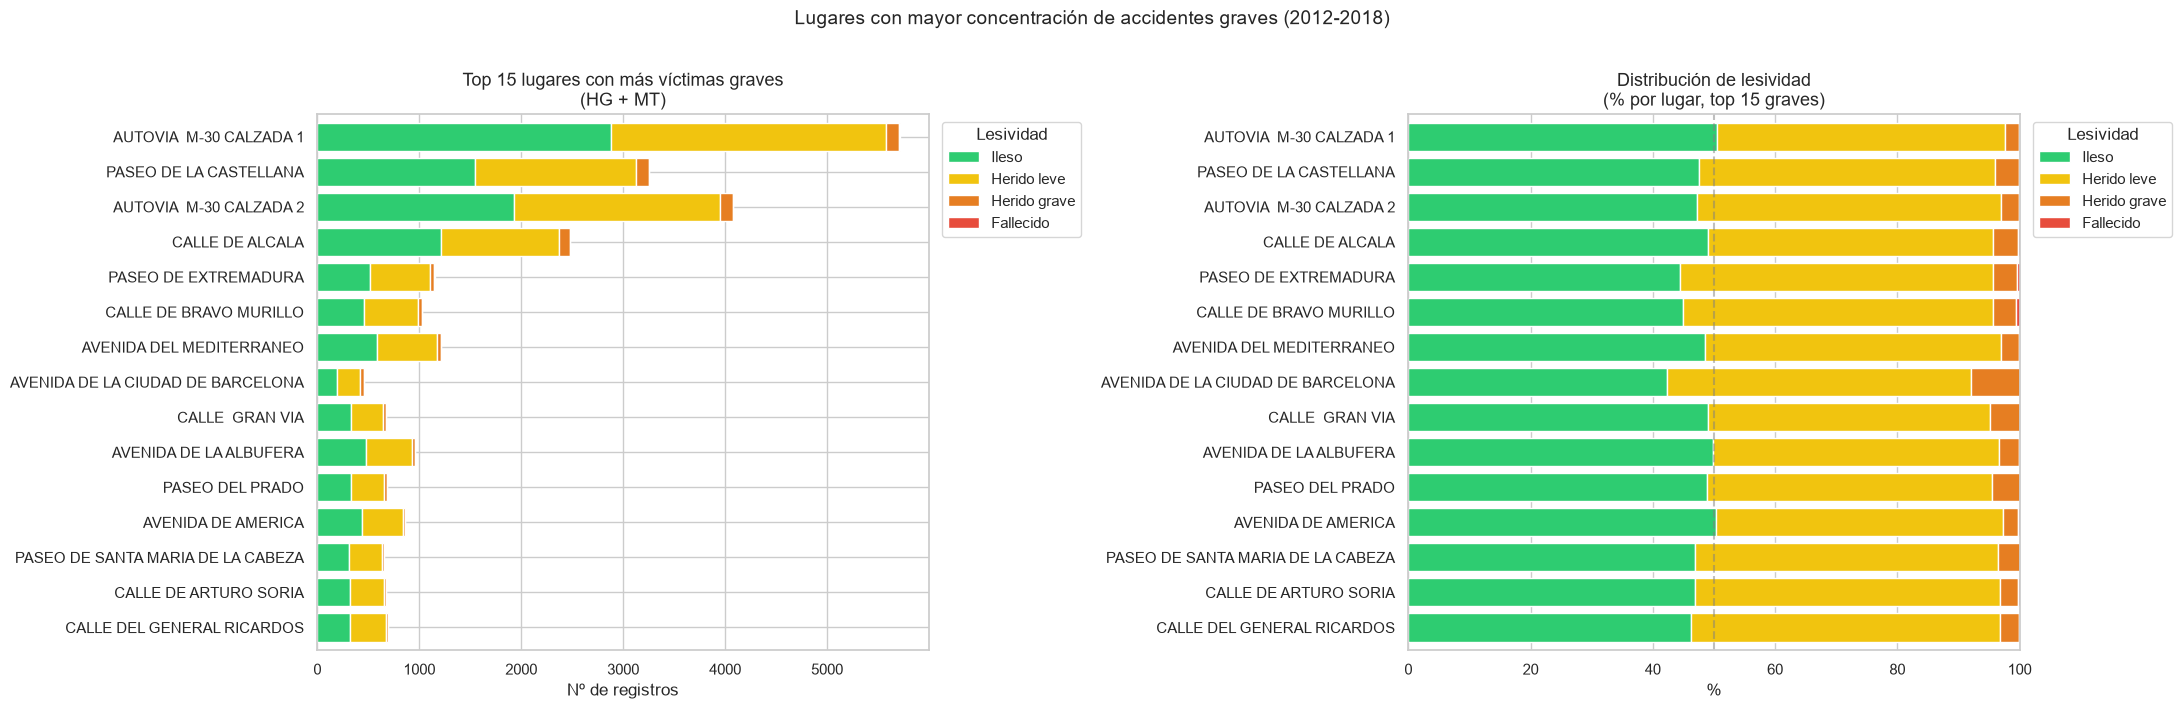

In [47]:
from src.utils.graficos import graficar_top_n_por_lesividad_grave

tabla_top, pct_top = graficar_top_n_por_lesividad_grave(
    lesividad_lugar, lesividad_lugar_pct, categorias_graves=['HG', 'MT'],
    orden_lesividad=ORDEN_LESIVIDAD, colores_lesividad=COLORES_LESIVIDAD, labels_lesividad=LABELS_LESIVIDAD_EXT[:4],
    n=15,
    titulo_abs='Top 15 lugares con más víctimas graves\n(HG + MT)',
    titulo_pct='Distribución de lesividad\n(% por lugar, top 15 graves)',
    suptitle='Lugares con mayor concentración de accidentes graves (2012-2018)',
    filename='../figures/09b_top15_graves.png'
)

### 9.2 Análisis de gravedad condiciones meteorológicas

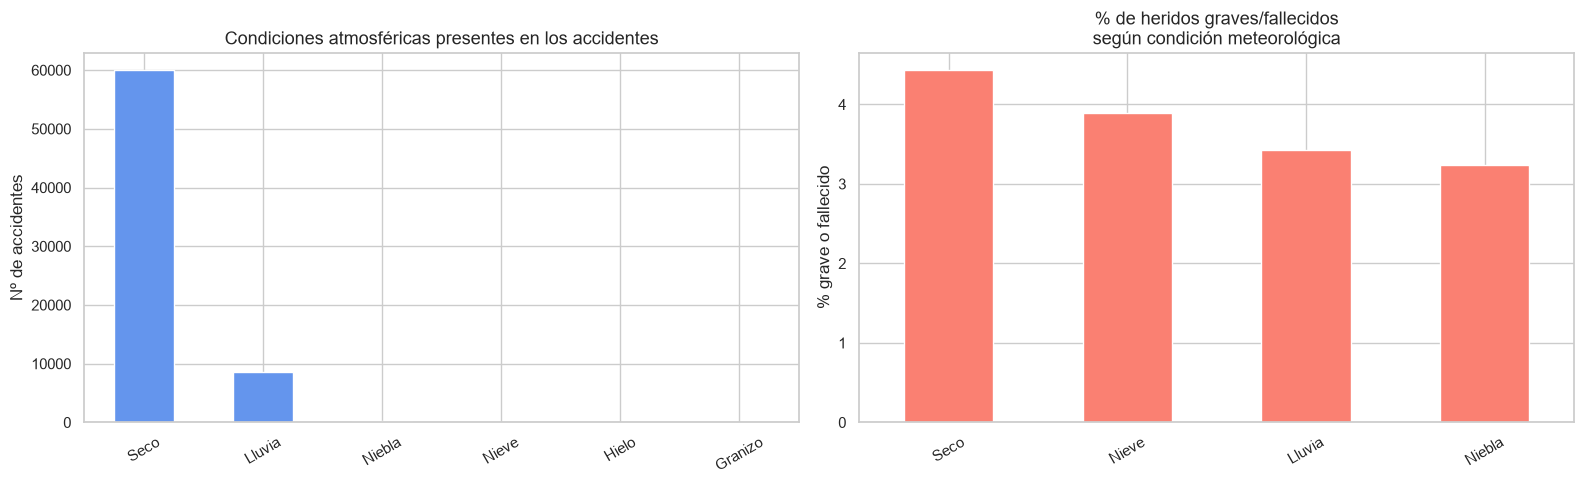

        Nº accidentes Porcentaje (%)  % graves
Granizo             9           0.01       NaN
Hielo              65           0.09       NaN
Lluvia           8535          12.41      3.43
Niebla            188           0.27      3.24
Nieve              68            0.1      3.90
Seco            59975          87.21      4.43


In [48]:
from src.utils.graficos import graficar_condicion_binaria

tabla_cpfa = graficar_condicion_binaria(
    df_accidentes, df_sin_na, prefijo='CPFA', color_barras='cornflowerblue', color_tasa='salmon',
    titulo_frecuencia='Condiciones atmosféricas presentes en los accidentes',
    titulo_tasa='% de heridos graves/fallecidos\nsegún condición meteorológica',
    filename='../figures/09c_condiciones_atmosfericas.png'
)

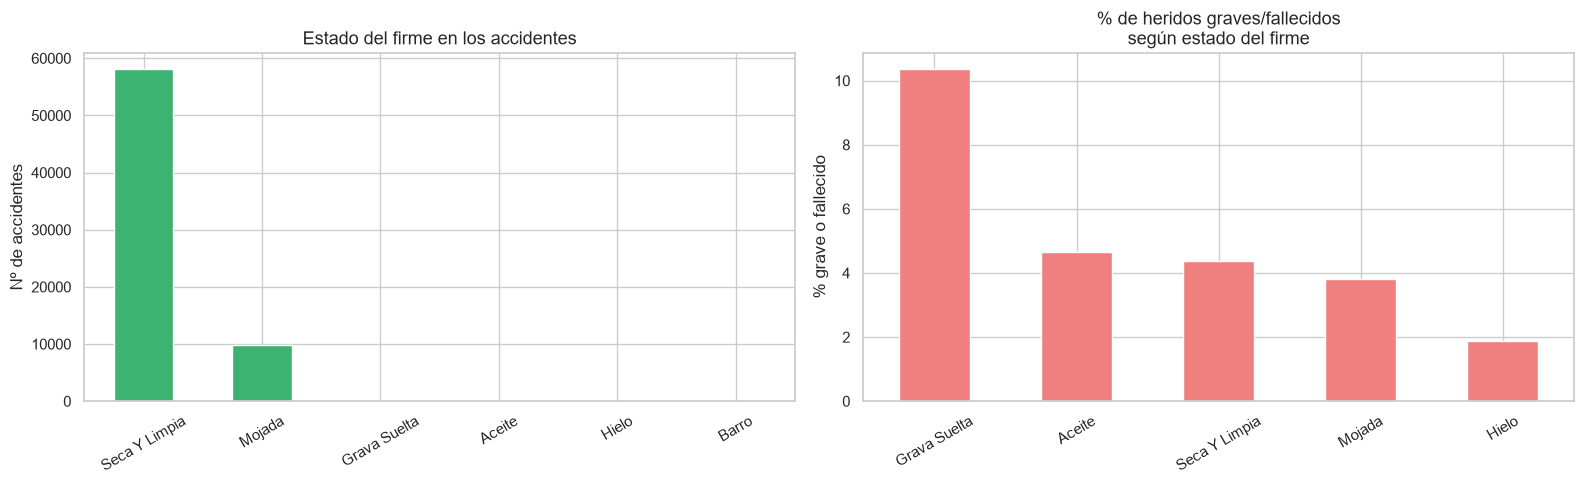

              Nº accidentes Porcentaje (%)  % graves
Aceite                  260           0.38      4.64
Barro                    59           0.09       NaN
Grava Suelta            273            0.4     10.35
Hielo                   102           0.15      1.89
Mojada                 9828          14.29      3.81
Seca Y Limpia         58073          84.44      4.37


In [49]:
tabla_cpsv = graficar_condicion_binaria(
    df_accidentes, df_sin_na, prefijo='CPSV', color_barras='mediumseagreen', color_tasa='lightcoral',
    titulo_frecuencia='Estado del firme en los accidentes',
    titulo_tasa='% de heridos graves/fallecidos\nsegún estado del firme',
    filename='../figures/09d_estado_firme.png'
)

### 📝 Resumen — Sección 9

> - El tipo de accidente más frecuente es **colisión doble** (>50%), seguido de atropello y caída de motocicleta. Sin embargo, el tipo con mayor proporción de heridos graves es **caída de bicicleta**.
> - La condición meteorológica predominante es **seco**, coherente con el clima de Madrid. No obstante, la tasa de graves es significativamente mayor cuando nieva o llueve.
> - El estado del firme con mayor tasa de accidentes graves es **grava suelta y aceite en la vía**, aunque son situaciones poco frecuentes. La gran mayoría de accidentes ocurren en firme seco y limpio.
> - La variable `LUGAR ACCIDENTE` muestra que los accidentes más graves ocurren en vías de mayor velocidad, mientras que las intersecciones y cruces concentran el mayor volumen de accidentes.

---
## 10. Análisis multivariante y asociación estadística

Se estudian las relaciones entre variables categóricas clave y la gravedad del accidente mediante:
1. **V de Cramér**: medida de asociación entre variables categóricas (0 = sin asociación, 1 = perfecta).
2. **Test chi-cuadrado**: contraste de independencia entre cada predictora y la variable objetivo.

> **Nota sobre el nivel de análisis (evita pseudo-replicación):**
> Cada variable se testea en el nivel al que realmente varía:
> - `TIPO PERSONA`, `SEXO`, `Tramo Edad`, `Tipo Vehiculo` son atributos de **persona**
>   (cambian entre los implicados de un mismo accidente) y se testean a nivel persona
>   (`df_sin_na`) frente a `GRAVE`. Su inclusión es intencional: cuantifica su relevancia
>   predictiva y orienta la estrategia de agregación en preprocesado (p. ej. presencia
>   de peatón, grupo de edad máxima, tipo de vehículo implicado).
> - `RANGO HORARIO`, `DIA SEMANA`, `DISTRITO`, `MES`, `TIPO ACCIDENTE` y las condiciones
>   `CPFA_*`/`CPSV_*` son atributos del **accidente**: toman el mismo valor para todos sus
>   implicados. Testearlas sobre `df_sin_na` repetiría cada accidente una vez por persona
>   implicada (pseudo-replicación), inflando artificialmente el tamaño muestral efectivo
>   y, con él, el chi² y el V de Cramér de esas variables. Por eso se testean sobre
>   `df_accidentes` frente a `accidente_grave`, que es el nivel real al que varían.


In [50]:
# Variables de PERSONA: varían entre implicados del mismo accidente -> se
# testean a nivel persona (df_sin_na) frente a GRAVE.
vars_persona = ['Tipo Vehiculo', 'TIPO PERSONA', 'SEXO', 'Tramo Edad']

# Variables de ACCIDENTE: mismo valor para todos los implicados de un mismo
# accidente -> se testean a nivel accidente (df_accidentes) frente a
# accidente_grave, para no pseudo-replicar (ver nota más arriba).
vars_accidente = [
    'RANGO HORARIO', 'DIA SEMANA', 'DISTRITO', 'MES', 'TIPO ACCIDENTE',
    *[c for c in df_accidentes.columns if c.startswith('CPFA') or c.startswith('CPSV')]
]

vars_categoricas = vars_persona + vars_accidente
print("Variables de persona (df_sin_na):", vars_persona)
print("Variables de accidente (df_accidentes):", vars_accidente)

# Corrección de Bonferroni para comparaciones múltiples
alpha_corregido = 0.05 / len(vars_categoricas)
print(f'\nNivel de significancia corregido (Bonferroni, n={len(vars_categoricas)}): {alpha_corregido:.4f}')

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)

resultados = []
for var in vars_persona:
    mask = df_sin_na[var].notna() & df_sin_na['LESIVIDAD'].notna()
    v_les = cramers_v(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'LESIVIDAD'])
    v_gra = cramers_v(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'GRAVE'].astype(str))
    resultados.append({'Variable': var, 'Nivel': 'Persona', 'V_Lesividad': v_les, 'V_Grave': v_gra})

for var in vars_accidente:
    mask = df_accidentes[var].notna() & df_accidentes['accidente_grave'].notna()
    v_gra = cramers_v(df_accidentes.loc[mask, var], df_accidentes.loc[mask, 'accidente_grave'].astype(str))
    resultados.append({'Variable': var, 'Nivel': 'Accidente', 'V_Lesividad': np.nan, 'V_Grave': v_gra})

df_cramer = pd.DataFrame(resultados).sort_values('V_Grave', ascending=False).reset_index(drop=True)
print('\nV de Cramér con la variable objetivo (cada variable testeada en su nivel correcto):')
print(df_cramer.round(4).to_string(index=False))

df_cramer['Variable'] = df_cramer['Variable'].str.title()


Variables de persona (df_sin_na): ['Tipo Vehiculo', 'TIPO PERSONA', 'SEXO', 'Tramo Edad']
Variables de accidente (df_accidentes): ['RANGO HORARIO', 'DIA SEMANA', 'DISTRITO', 'MES', 'TIPO ACCIDENTE', 'CPFA Granizo', 'CPFA Hielo', 'CPFA Lluvia', 'CPFA Niebla', 'CPFA Seco', 'CPFA Nieve', 'CPSV Mojada', 'CPSV Aceite', 'CPSV Barro', 'CPSV Grava Suelta', 'CPSV Hielo', 'CPSV Seca Y Limpia']

Nivel de significancia corregido (Bonferroni, n=21): 0.0024



V de Cramér con la variable objetivo (cada variable testeada en su nivel correcto):
          Variable     Nivel  V_Lesividad  V_Grave
      TIPO PERSONA   Persona       0.2171   0.2158
     Tipo Vehiculo   Persona       0.2879   0.2065
    TIPO ACCIDENTE Accidente          NaN   0.1720
        Tramo Edad   Persona       0.0863   0.0819
     RANGO HORARIO Accidente          NaN   0.0615
         CPFA Seco Accidente          NaN   0.0363
       CPFA Lluvia Accidente          NaN   0.0345
CPSV Seca Y Limpia Accidente          NaN   0.0286
       CPSV Mojada Accidente          NaN   0.0283
        DIA SEMANA Accidente          NaN   0.0216
              SEXO   Persona       0.0924   0.0211
          DISTRITO Accidente          NaN   0.0183
        CPSV Hielo Accidente          NaN   0.0071
 CPSV Grava Suelta Accidente          NaN   0.0062
       CPFA Niebla Accidente          NaN   0.0049
        CPFA Hielo Accidente          NaN   0.0046
       CPSV Aceite Accidente          NaN   0.00

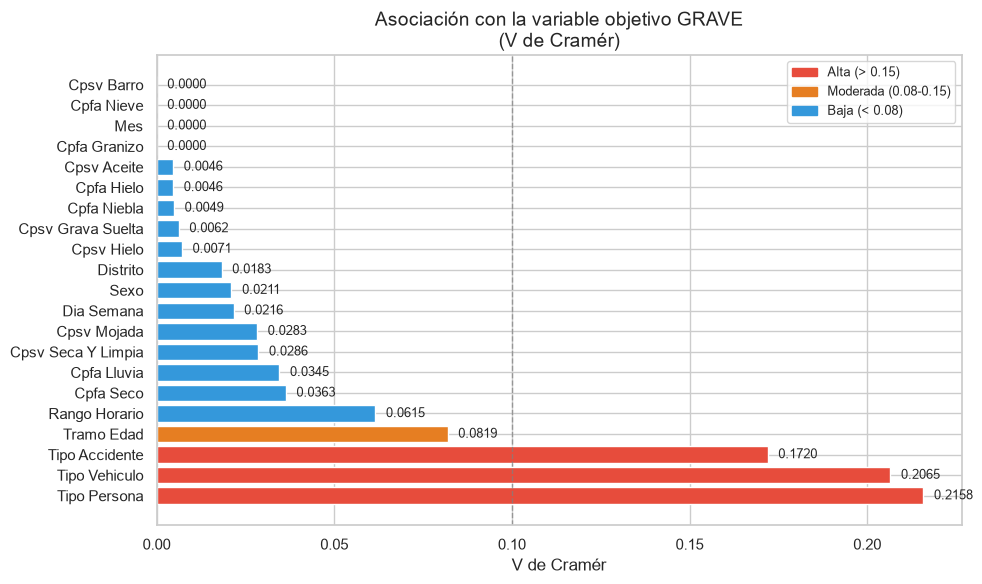

In [51]:
# Visualización: ranking de V de Cramér con GRAVE
fig, ax = plt.subplots(figsize=(10, 6))

colores_cv = ['#e74c3c' if v > 0.15 else '#e67e22' if v > 0.08 else '#3498db'
              for v in df_cramer['V_Grave']]
bars = ax.barh(df_cramer['Variable'], df_cramer['V_Grave'], color=colores_cv)

for bar, val in zip(bars, df_cramer['V_Grave']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.axvline(0.10, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Umbral moderado (0.10)')
ax.set_title('Asociación con la variable objetivo GRAVE\n(V de Cramér)', fontsize=14)
ax.set_xlabel('V de Cramér')
ax.legend()

from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label='Alta (> 0.15)'),
           Patch(color='#e67e22', label='Moderada (0.08-0.15)'),
           Patch(color='#3498db', label='Baja (< 0.08)')]
ax.legend(handles=leyenda, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/10a_cramer_v_asociacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# Tests chi-cuadrado: independencia entre cada variable y su target al nivel
# correcto (GRAVE a nivel persona / accidente_grave a nivel accidente, según
# corresponda - ver nota de la Sección 10)
# + verificación del supuesto de frecuencia esperada (Cochran: idealmente
#   ninguna celda esperada < 5, se tolera hasta un 20% de celdas por debajo
#   de ese umbral si ninguna es < 1)
print(f'Test chi-cuadrado (H0: independencia entre variable y gravedad, cada una en su nivel)')
print(f'{"Variable":<25} {"Nivel":>10} {"chi2":>12} {"p-valor":>15} {"Sig.":>6} {"% cel<5":>9} {"Válido":>8}')
print('-' * 100)

resultados_chi2 = []

def _test_chi2(x, y, var, nivel):
    ct = pd.crosstab(x, y)
    chi2_val, p_val, dof, expected = chi2_contingency(ct)

    pct_celdas_bajas = (expected < 5).mean() * 100
    hay_celda_bajo_1 = (expected < 1).any()
    supuesto_ok = (pct_celdas_bajas <= 20) and not hay_celda_bajo_1

    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < alpha_corregido else 'ns'
    validez = 'OK' if supuesto_ok else 'REVISAR'

    resultados_chi2.append({
        'Variable': var, 'Nivel': nivel, 'chi2': chi2_val, 'p_valor': p_val,
        'pct_celdas_esperada_menor_5': pct_celdas_bajas,
        'alguna_celda_menor_1': hay_celda_bajo_1,
        'supuesto_valido': supuesto_ok,
    })
    print(f'{var:<25} {nivel:>10} {chi2_val:>12.1f} {p_val:>15.2e} {sig:>6} {pct_celdas_bajas:>8.1f}% {validez:>8}')

for var in vars_persona:
    mask = df_sin_na[var].notna() & df_sin_na['GRAVE'].notna()
    _test_chi2(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'GRAVE'], var, 'Persona')

for var in vars_accidente:
    mask = df_accidentes[var].notna() & df_accidentes['accidente_grave'].notna()
    _test_chi2(df_accidentes.loc[mask, var], df_accidentes.loc[mask, 'accidente_grave'], var, 'Accidente')

print(f'\nSignificancia (Bonferroni α={alpha_corregido:.4f}): *** p<0.001 | ** p<0.01 | * p<alpha_corregido | ns = no significativo')
print('Válido: regla de Cochran (≤20% de celdas con frecuencia esperada <5, ninguna <1)')

df_chi2_check = pd.DataFrame(resultados_chi2)
n_revisar = (~df_chi2_check['supuesto_valido']).sum()
if n_revisar > 0:
    print(f'\n⚠️  {n_revisar} variable(s) incumplen el supuesto de frecuencia esperada del chi-cuadrado:')
    print(df_chi2_check.loc[~df_chi2_check['supuesto_valido'],
                             ['Variable', 'Nivel', 'pct_celdas_esperada_menor_5', 'alguna_celda_menor_1']].to_string(index=False))
    print('  → Para estas variables, el p-valor puede estar sesgado (habitualmente hacia significancia).')
    print('  → Alternativa más robusta: test exacto de Fisher (tablas 2xK) o agrupar categorías')
    print('    raras en una categoría "Otros" antes de repetir el test.')
else:
    print('\n✓ Todas las variables cumplen el supuesto de frecuencia esperada del chi-cuadrado.')


Test chi-cuadrado (H0: independencia entre variable y gravedad, cada una en su nivel)
Variable                       Nivel         chi2         p-valor   Sig.   % cel<5   Válido
----------------------------------------------------------------------------------------------------
Tipo Vehiculo                Persona       6499.1        0.00e+00    ***      4.5%       OK
TIPO PERSONA                 Persona       7630.9        0.00e+00    ***      0.0%       OK
SEXO                         Persona         73.4        1.04e-17    ***      0.0%       OK


Tramo Edad                   Persona       1099.4       5.57e-224    ***      0.0%       OK
RANGO HORARIO              Accidente        283.5        9.83e-47    ***      0.0%       OK
DIA SEMANA                 Accidente         38.2        1.01e-06    ***      0.0%       OK
DISTRITO                   Accidente         43.0        2.07e-03     **      0.0%       OK
MES                        Accidente          4.9        9.34e-01     ns      0.0%       OK
TIPO ACCIDENTE             Accidente       2043.7        0.00e+00    ***      4.5%  REVISAR
CPFA Granizo               Accidente          0.2        6.80e-01     ns     25.0%  REVISAR
CPFA Hielo                 Accidente          2.5        1.15e-01     ns      0.0%       OK
CPFA Lluvia                Accidente         83.0        8.20e-20    ***      0.0%       OK


CPFA Niebla                Accidente          2.6        1.04e-01     ns      0.0%       OK
CPFA Seco                  Accidente         91.9        9.33e-22    ***      0.0%       OK
CPFA Nieve                 Accidente          0.0        9.90e-01     ns      0.0%       OK
CPSV Mojada                Accidente         55.9        7.48e-14    ***      0.0%       OK
CPSV Aceite                Accidente          2.5        1.15e-01     ns      0.0%       OK
CPSV Barro                 Accidente          0.1        7.12e-01     ns      0.0%       OK
CPSV Grava Suelta          Accidente          3.7        5.60e-02     ns      0.0%       OK
CPSV Hielo                 Accidente          4.5        3.43e-02     ns      0.0%       OK
CPSV Seca Y Limpia         Accidente         57.3        3.76e-14    ***      0.0%       OK

Significancia (Bonferroni α=0.0024): *** p<0.001 | ** p<0.01 | * p<alpha_corregido | ns = no significativo
Válido: regla de Cochran (≤20% de celdas con frecuencia esperada

In [53]:
# Fusionar la única categoría de TIPO ACCIDENTE con muestra insuficiente
# (CAÍDA VEHÍCULO 3 RUEDAS) con la categoría residual ya existente en el
# dataset (OTRAS CAUSAS), en vez de crear un grupo "OTROS" nuevo y vacío
# — crear un grupo nuevo con una única categoría rara no soluciona nada,
# porque sigue teniendo la misma frecuencia baja, solo que renombrada.
# Se aplica sobre df_accidentes: TIPO ACCIDENTE es una variable de accidente
# y se testea a ese nivel (ver nota de la Sección 10).
df_accidentes['TIPO ACCIDENTE_AGRUP'] = df_accidentes['TIPO ACCIDENTE'].replace(
    {'CAÍDA VEHÍCULO 3 RUEDAS': 'OTRAS CAUSAS'}
)

mask = df_accidentes['TIPO ACCIDENTE_AGRUP'].notna() & df_accidentes['accidente_grave'].notna()
ct = pd.crosstab(df_accidentes.loc[mask, 'TIPO ACCIDENTE_AGRUP'], df_accidentes.loc[mask, 'accidente_grave'])
chi2_val, p_val, dof, expected = chi2_contingency(ct)
pct_bajas = (expected < 5).mean() * 100
print(f'TIPO ACCIDENTE (fusionado con OTRAS CAUSAS, nivel accidente) — chi2={chi2_val:.1f}, p={p_val:.2e}, '
      f'% celdas<5={pct_bajas:.1f}%, celda<1: {(expected < 1).any()}')


TIPO ACCIDENTE (fusionado con OTRAS CAUSAS, nivel accidente) — chi2=2043.2, p=0.00e+00, % celdas<5=0.0%, celda<1: False


In [54]:
from scipy.stats import fisher_exact

variables_revisar_fisher = ['CPFA Granizo', 'CPFA Hielo', 'CPSV Barro']

print('Test exacto de Fisher (confirmación para tablas 2x2 con muestra pequeña, nivel accidente):')
print(f'{"Variable":<20} {"n (SI)":>8} {"Odds Ratio":>12} {"p-valor Fisher":>16} {"p-valor chi2":>14}')
print('-' * 75)

for var in variables_revisar_fisher:
    mask = df_accidentes[var].notna() & df_accidentes['accidente_grave'].notna()
    ct = pd.crosstab(df_accidentes.loc[mask, var], df_accidentes.loc[mask, 'accidente_grave'])
    n_si = int(ct.loc['SI'].sum()) if 'SI' in ct.index else 0
    odds_ratio, p_fisher = fisher_exact(ct)
    chi2_val, p_chi2, _, _ = chi2_contingency(ct)
    print(f'{var:<20} {n_si:>8} {odds_ratio:>12.3f} {p_fisher:>16.4e} {p_chi2:>14.4e}')

print('\nSi Fisher también da "ns": la conclusión correcta es que la muestra es')
print('demasiado pequeña para confirmar o descartar asociación — no que')
print('"no hay relación". Debe tratarse como limitación, no como hallazgo.')


Test exacto de Fisher (confirmación para tablas 2x2 con muestra pequeña, nivel accidente):
Variable               n (SI)   Odds Ratio   p-valor Fisher   p-valor chi2
---------------------------------------------------------------------------
CPFA Granizo                9        0.000       1.0000e+00     6.8026e-01
CPFA Hielo                 65        0.299       8.8675e-02     1.1504e-01
CPSV Barro                 59        1.268       5.0681e-01     7.1221e-01

Si Fisher también da "ns": la conclusión correcta es que la muestra es
demasiado pequeña para confirmar o descartar asociación — no que
"no hay relación". Debe tratarse como limitación, no como hallazgo.


> **Limitación — condiciones meteorológicas/de firme extremadamente raras**
>
> `CPFA Granizo`, `CPFA Hielo` y `CPSV Barro` (n de accidentes con la condición presente,
> mostrado en la celda anterior) no cumplen el supuesto de frecuencia esperada del
> chi-cuadrado y, además, tienen un tamaño muestral demasiado pequeño para que ningún
> test (ni siquiera Fisher exacto) tenga potencia suficiente. El resultado "no
> significativo" en estos casos **no debe interpretarse como ausencia de asociación
> real**, sino como imposibilidad de concluir con los datos disponibles. `TIPO ACCIDENTE`,
> en cambio, sí se confirma como significativa tras agrupar sus categorías raras.


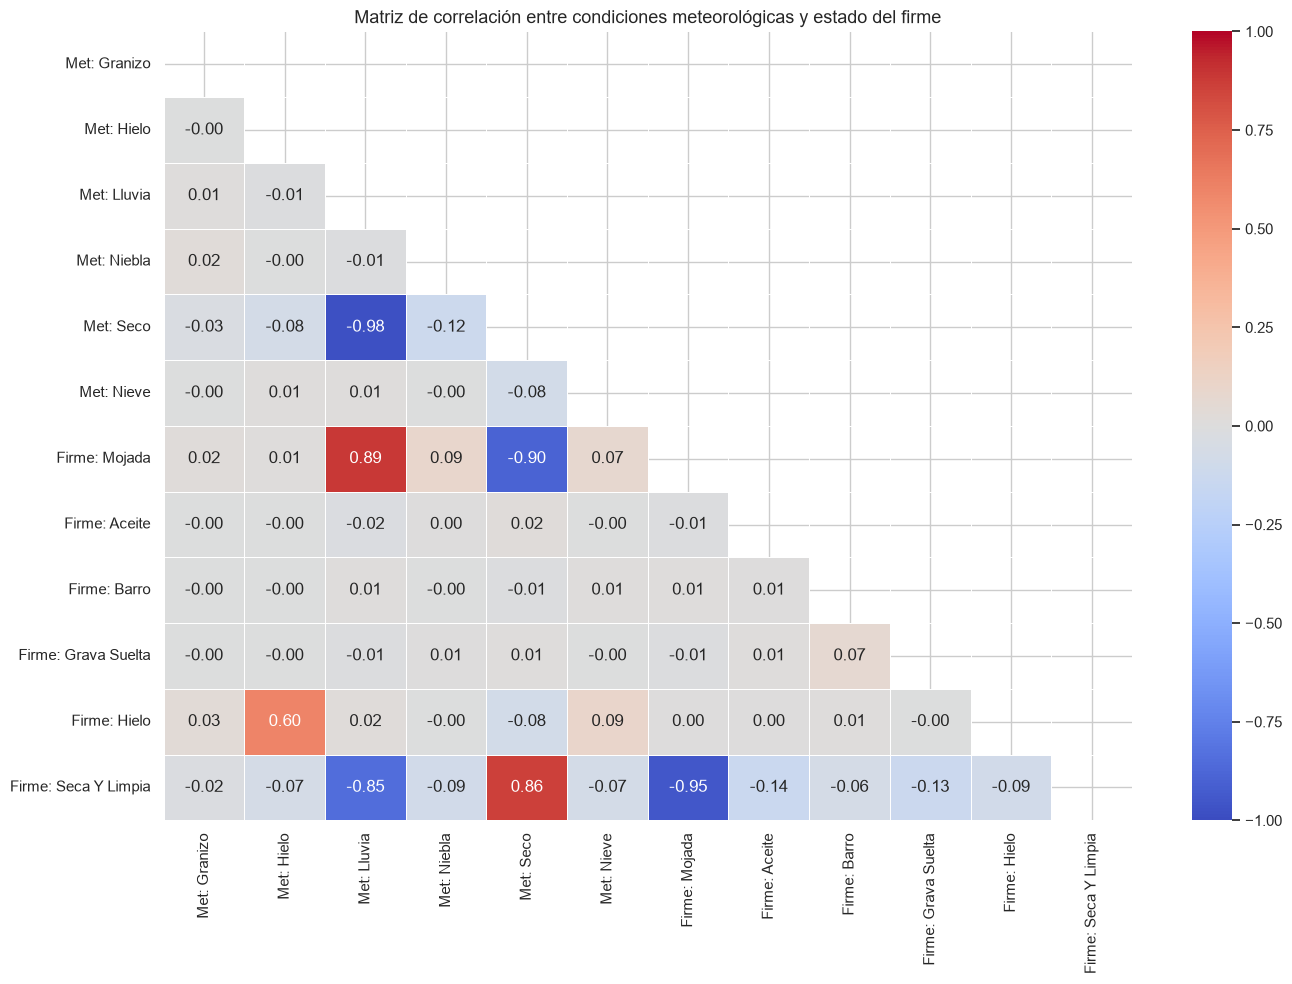

In [55]:
# Heatmap de co-ocurrencia entre condiciones CPFA y CPSV (nivel accidente)
cols_cond = [c for c in df_accidentes.columns if c.startswith('CPFA') or c.startswith('CPSV')]

# Convertir a binario
cond_binary = df_accidentes[cols_cond].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cond_binary.columns = [c.replace('CPFA ', 'Met: ').replace('CPSV ', 'Firme: ') for c in cond_binary.columns]

corr_cond = cond_binary.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask_tri = np.triu(np.ones_like(corr_cond, dtype=bool))
sns.heatmap(corr_cond, mask=mask_tri, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación entre condiciones meteorológicas y estado del firme', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/10b_heatmap_condiciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.2 Análisis de interacciones entre variables clave

Se estudian tres interacciones clave mediante heatmaps de tasa de gravedad (% HG+MT):
1. **Tipo de persona × Tipo de accidente**: ¿varía la gravedad del mismo tipo de accidente según el perfil de la víctima?
3. **Tipo de vehículo × Grupo de edad**: ¿actúa la edad como factor modificador del riesgo según el vehículo?

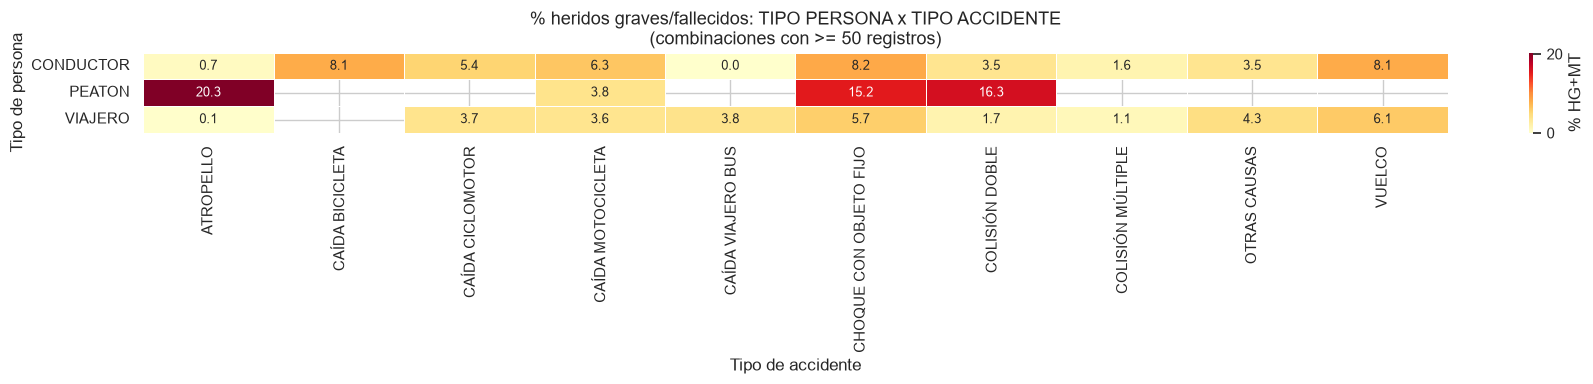

In [56]:
# Interacción 1: TIPO PERSONA × TIPO ACCIDENTE — % HG+MT
pivot_int1=(df_sin_na.groupby(['TIPO PERSONA','TIPO ACCIDENTE'])['GRAVE']
            .agg(['mean','count']).reset_index())
pivot_int1.columns=['TIPO PERSONA','TIPO ACCIDENTE','pct_grave','n']
pivot_int1['pct_grave']*=100; pivot_int1=pivot_int1[pivot_int1['n']>=50]
hm1=pivot_int1.pivot_table(index='TIPO PERSONA',columns='TIPO ACCIDENTE',values='pct_grave')
fig,ax=plt.subplots(figsize=(18,4))
sns.heatmap(hm1,annot=True,fmt='.1f',cmap='YlOrRd',ax=ax,linewidths=0.5,
            cbar_kws={'label':'% HG+MT'},annot_kws={'size':9})
ax.set_title('% heridos graves/fallecidos: TIPO PERSONA x TIPO ACCIDENTE\n(combinaciones con >= 50 registros)',fontsize=13)
ax.set_xlabel('Tipo de accidente'); ax.set_ylabel('Tipo de persona')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')
plt.tight_layout(); plt.savefig('../figures/10c_interaccion_persona_accidente.png',dpi=150,bbox_inches='tight'); plt.show()

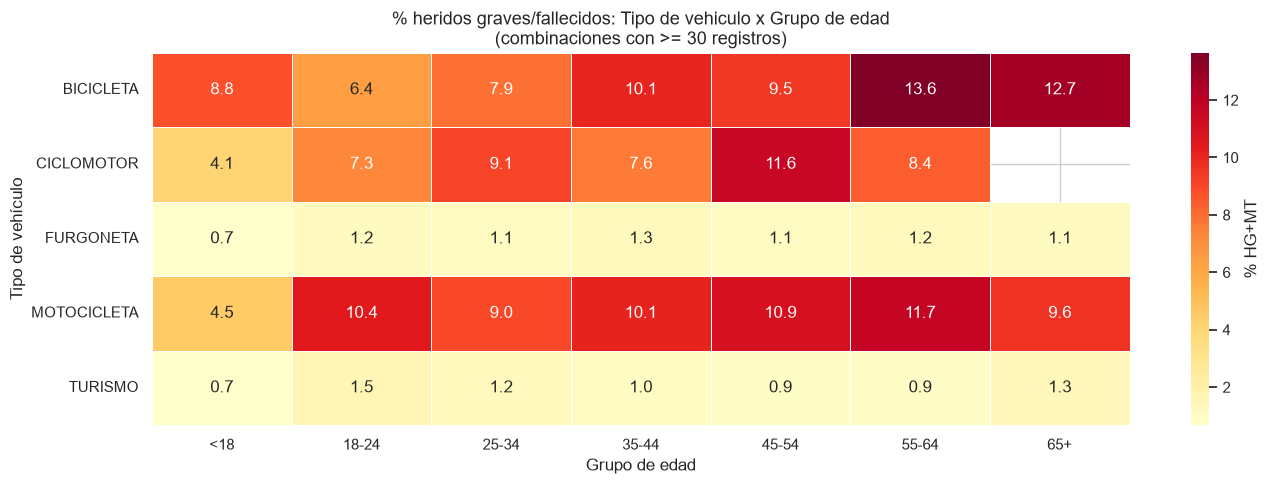

In [57]:
# Interacción 2: Tipo de vehículo × Grupo de edad — % HG+MT
grupos_por_tramo = [
    '<18', '<18', '<18', '<18',
    '18-24', '18-24',
    '25-34', '25-34',
    '35-44', '35-44',
    '45-54', '45-54',
    '55-64', '55-64',
    '65+', '65+', '65+'
]

tramos_edad = [e for e in orden_edad if e != 'Sin dato']
assert len(tramos_edad) == len(grupos_por_tramo), 'Cada tramo de orden_edad debe tener asignado un grupo'
g_edad = dict(zip(tramos_edad, grupos_por_tramo))

orden_ge = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
vehs = ['TURISMO', 'MOTOCICLETA', 'CICLOMOTOR', 'BICICLETA', 'FURGONETA']
df3 = df_sin_na.dropna(subset=['Tramo Edad', 'Tipo Vehiculo']).copy()
df3['Grupo Edad'] = df3['Tramo Edad'].map(g_edad)
df3 = df3[df3['Tipo Vehiculo'].isin(vehs)].dropna(subset=['Grupo Edad'])
p3 = df3.groupby(['Tipo Vehiculo', 'Grupo Edad'])['GRAVE'].agg(['mean', 'count']).reset_index()
p3.columns = ['Tipo Vehiculo', 'Grupo Edad', 'pct_grave', 'n']
p3 = p3[p3['n'] >= 30]; p3['pct_grave'] *= 100
hm3 = p3.pivot_table(index='Tipo Vehiculo', columns='Grupo Edad', values='pct_grave').reindex(columns=orden_ge)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(hm3, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5, cbar_kws={'label': '% HG+MT'})
ax.set_title('% heridos graves/fallecidos: Tipo de vehiculo x Grupo de edad\n(combinaciones con >= 30 registros)', fontsize=13)
ax.set_xlabel('Grupo de edad'); ax.set_ylabel('Tipo de vehículo')
plt.tight_layout(); plt.savefig('../figures/10d_interaccion_vehiculo_edad.png', dpi=150, bbox_inches='tight'); plt.show()

### 📝 Resumen — Sección 10

> - Tras corregir la pseudo-replicación (ver nota metodológica más arriba), la
>   **V de Cramér** confirma que `TIPO PERSONA` (0.216) y `Tipo Vehiculo` (0.207) son las
>   variables con mayor asociación con la gravedad, seguidas de `TIPO ACCIDENTE` (0.172,
>   ya a nivel accidente) y `Tramo Edad` (0.082). El resto de variables de accidente
>   (`RANGO HORARIO`, `DISTRITO`, `DIA SEMANA`, condiciones `CPFA_*`/`CPSV_*`) quedan por
>   debajo de 0.07 una vez medidas en su nivel correcto — bastante más bajo de lo que
>   sugería el cálculo original sobre `df_sin_na`, donde su tamaño muestral estaba
>   artificialmente inflado por repetir cada accidente una vez por implicado.
> - `DISTRITO` en concreto queda con la V de Cramér más baja de toda la tabla (0.018),
>   coherente con la Sección 5, donde ya se observó que apenas diferenciaba entre clases.
> - El test chi-cuadrado, ya corregido por nivel, mantiene significativas
>   (p < 0.0024 tras Bonferroni) `TIPO PERSONA`, `Tipo Vehiculo`, `SEXO`, `Tramo Edad`,
>   `RANGO HORARIO`, `DIA SEMANA`, `DISTRITO`, `TIPO ACCIDENTE`, `CPFA Lluvia`, `CPFA Seco`,
>   `CPSV Mojada` y `CPSV Seca Y Limpia`. No resultan significativas `MES`, `CPFA Granizo`,
>   `CPFA Hielo`, `CPFA Niebla`, `CPFA Nieve`, `CPSV Aceite`, `CPSV Barro`, `CPSV Grava Suelta`
>   y `CPSV Hielo` — casi todas condiciones meteorológicas/de firme muy poco frecuentes cuya
>   significancia no puede confirmarse ni descartarse por tamaño muestral insuficiente (ver
>   nota de limitación anterior). `CPSV Grava Suelta` pasa a ser "ns" con la corrección de
>   nivel, cuando antes aparecía como significativa: es exactamente el tipo de falso
>   positivo por pseudo-replicación que motivó la corrección.
> - Se verificaron los supuestos del test chi-cuadrado (frecuencia esperada por celda).
>   `TIPO ACCIDENTE` incumplía el supuesto por su alta cardinalidad; tras agrupar sus
>   categorías más raras, el resultado significativo se confirma con garantías. Las tres
>   condiciones más raras (`CPFA Granizo`, `CPFA Hielo`, `CPSV Barro`) se confirmaron además
>   con el test exacto de Fisher a nivel accidente.
> - El heatmap de condiciones meteorológicas y estado del firme muestra correlaciones
>   esperables (ej. lluvia y firme mojado), lo que podría justificar combinar algunas de
>   estas variables binarias en índices compuestos durante el preprocesado.

### 📝 Resumen — Sección 10.2 (Interacciones)

> - **Persona × Tipo accidente:** Los peatones atropellados presentan la tasa de HG+MT
>   más alta. La caída de bicicleta tiene gravedad muy diferente según el tipo de implicado.
> - **Vehículo × Edad:** Los mayores de 65 muestran mayor gravedad independientemente del
>   vehículo. Estas interacciones sugieren que la combinación edad + vehículo puede tener
>   mayor capacidad predictiva que cada variable por separado.


---
## 11. Conclusiones del EDA

En esta sección se recogen los hallazgos más relevantes del análisis exploratorio y se extraen las implicaciones para la fase de preprocesado y modelización.

### Variables más prometedoras para el modelo

| Variable | Tipo | V Cramér (nivel correcto) | Observación |
|----------|------|-------------------|-------------|
| `TIPO PERSONA` | Categórica | Alta (0.216) | Los peatones presentan la mayor tasa de HG+MT |
| `Tipo Vehiculo` | Categórica | Alta (0.207) | Motocicletas y bicicletas con mayor gravedad |
| `TIPO ACCIDENTE` | Categórica | Alta (0.172) | Alta variabilidad en gravedad según tipo |
| `Tramo Edad` | Categórica | Moderada (0.082) | Mayores de 65 y menores de 18 más vulnerables |
| `LUGAR ACCIDENTE` | Categórica | (no testeada con V de Cramér, cardinalidad muy alta) | Vías de alta velocidad vs. intersecciones — evidencia descriptiva en Sección 9 |
| `RANGO HORARIO` | Categórica | Baja (0.062) | Accidentes nocturnos con mayor tasa de gravedad |
| `SEXO` | Categórica | Baja (0.021) | Gravedad relativa similar entre hombres y mujeres |
| `DIA SEMANA` | Categórica | Baja (0.022) | Diferencias entre laborables y fin de semana |
| `DISTRITO` | Categórica | Baja (0.018) | Apenas diferencia la gravedad (sí el volumen, ver Sección 8) |
| `CPFA_*` | Binaria | Baja (0.00-0.04) | Lluvia y firme seco/mojado significativos; el resto, muestra insuficiente |
| `CPSV_*` | Binaria | Baja (0.00-0.03) | Firme mojado y seco/limpio significativos; el resto, muestra insuficiente |


### Decisiones tomadas para la fase de preprocesado

> 1. La variable objetivo se construirá como la **LESIVIDAD máxima por accidente** (`Nº PARTE`)
> 2. Los testigos ya han sido excluidos en este notebook
> 3. Se eliminarán las **4.065 filas duplicadas exactas** (errores de registro)
> 4. Se eliminarán los **7.860 registros con `LESIVIDAD = 'NO ASIGNADA'`**
> 5. Se usará **clasificación binaria**: Leve/Sin heridos vs. Grave/Fallecido
> 6. El dataset presenta un **desequilibrio de clases severo a nivel accidente (~9.6% graves, ratio ~9:1)**. A nivel persona el ratio es ~25:1, pero la referencia para el modelo es el nivel accidente: se abordará con `class_weight='balanced'`, SMOTE o umbral de clasificación ajustado en la fase de modelización
> 7. La variable numérica `Nº VICTIMAS *` presenta **distribución no normal y asimétrica**: se evaluará su transformación logarítmica o de raíz cuadrada
> 8. Las variables `CPFA_*` y `CPSV_*` ya son binarias y no requieren codificación adicional
> 9. Las variables categóricas nominales requerirán **codificación ordinal o one-hot** según el modelo elegido

In [58]:
# Resumen final del EDA
print('=== RESUMEN DEL EDA ===')
print(f'Total registros (sin testigos):   {len(df):>10,}')
print(f'Total accidentes únicos:          {df["Nº PARTE"].nunique():>10,}')
print(f'Período:                          {df["FECHA"].min().date()} — {df["FECHA"].max().date()}')
print(f'\nDistribución de LESIVIDAD (nivel persona):')
print(df['LESIVIDAD'].value_counts(normalize=True).mul(100).round(2).to_string())
pct_graves = df.loc[df['LESIVIDAD'].notna(), 'LESIVIDAD'].isin(['HG','MT']).mean()*100
print(f'\nDesequilibrio de clases (HG+MT vs resto): {pct_graves:.2f}% graves')
print(f'Ratio aproximado: {(100-pct_graves)/pct_graves:.1f}:1')

=== RESUMEN DEL EDA ===
Total registros (sin testigos):      170,288
Total accidentes únicos:              68,773
Período:                          2012-01-01 — 2018-12-31

Distribución de LESIVIDAD (nivel persona):
LESIVIDAD
HL    48.68
IL    47.01
HG     4.18
MT     0.13

Desequilibrio de clases (HG+MT vs resto): 4.31% graves
Ratio aproximado: 22.2:1
